# QFC Kaggle Competition 
This notebook is a practice notebook for QFC'25 Kaggle competition, our goal is to understand Time series data, model this using various models and predict the value of next 200 datapoints. We will submit a csv file of next 200 data points for evaluation.

* Demonstrated hands-on mastery of time series modeling of Wvap by performing all transformations, model fitting, and forecast reconstruction without automated libraries like auto_arima, showcasing a deep understanding of SARIMA modeling from first principles. 

* Built and validated an SARIMA model for univariate forecasting using custom-tuned parameters based on manual analysis of ACF/PACF plots, ADF stationarity tests, and Fourier decomposition to detect seasonality cycles.

* confirmed stationarity using ADF p-values, and restored predictions via iterative reconstruction of differenced components, demonstrating full-cycle model understanding.

* Manually selected (p,d,q)(P,D,Q,S) parameters of SARIMA and got RMSE of 7.4 with 4th position in kaggle leadership board.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('TRAINING_DATA-TSAC - time_data.csv')
df.set_index('Id',inplace=True)
df

,Values
Id,
0,2.834420
1,4.279164
2,1.598206
3,0.069473
4,0.232714
...,...
796,286.592993
797,286.195649
798,285.752718


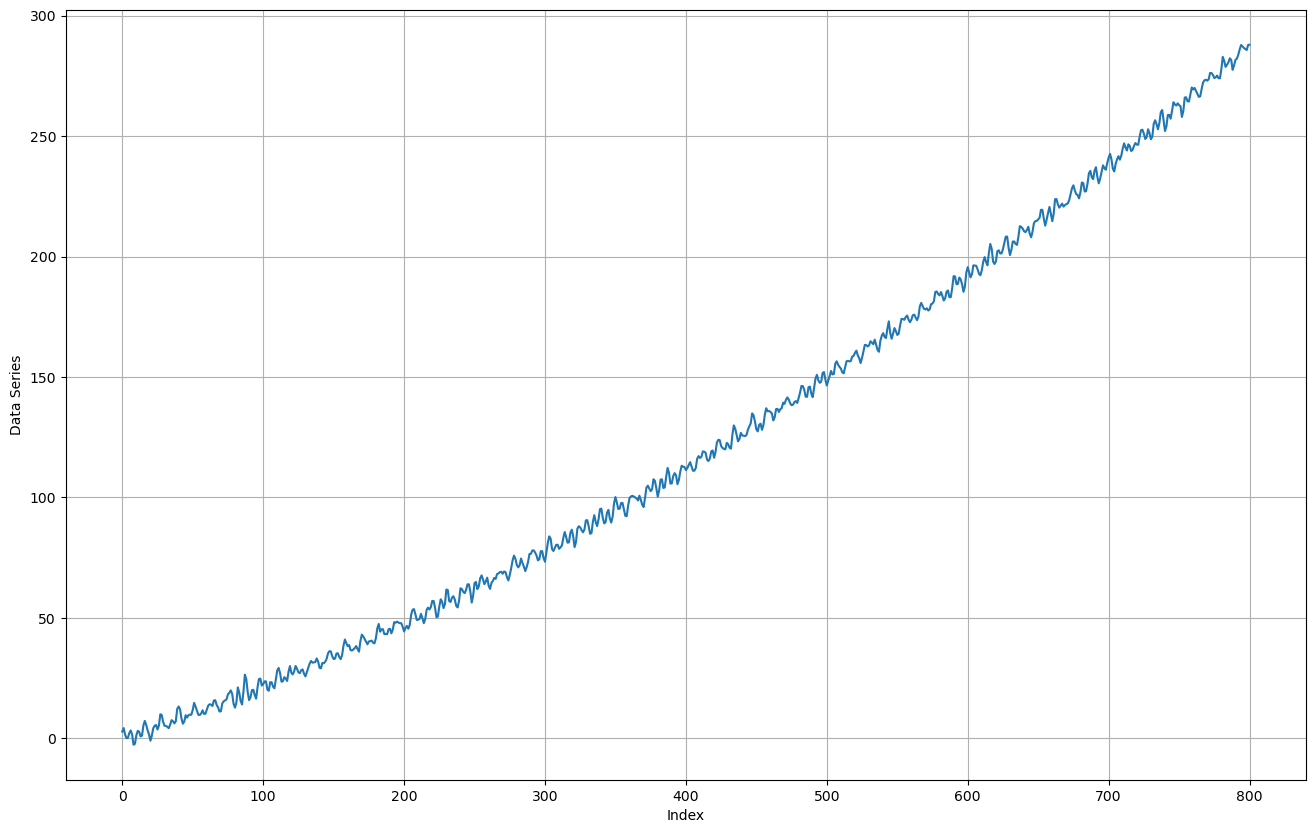

In [3]:
plt.figure(figsize=(16,10))
plt.plot(df)
plt.grid()
plt.xlabel('Index')
plt.ylabel('Data Series')
plt.show()

The Data preliminary looks like a trending time series data with a regular pattern of seasonality present, we will find out more about this data when we decompose the time series data. This data is not stationary because it has rising mean. Let's see zoomed in data to see if we can detect any seasonality pattern

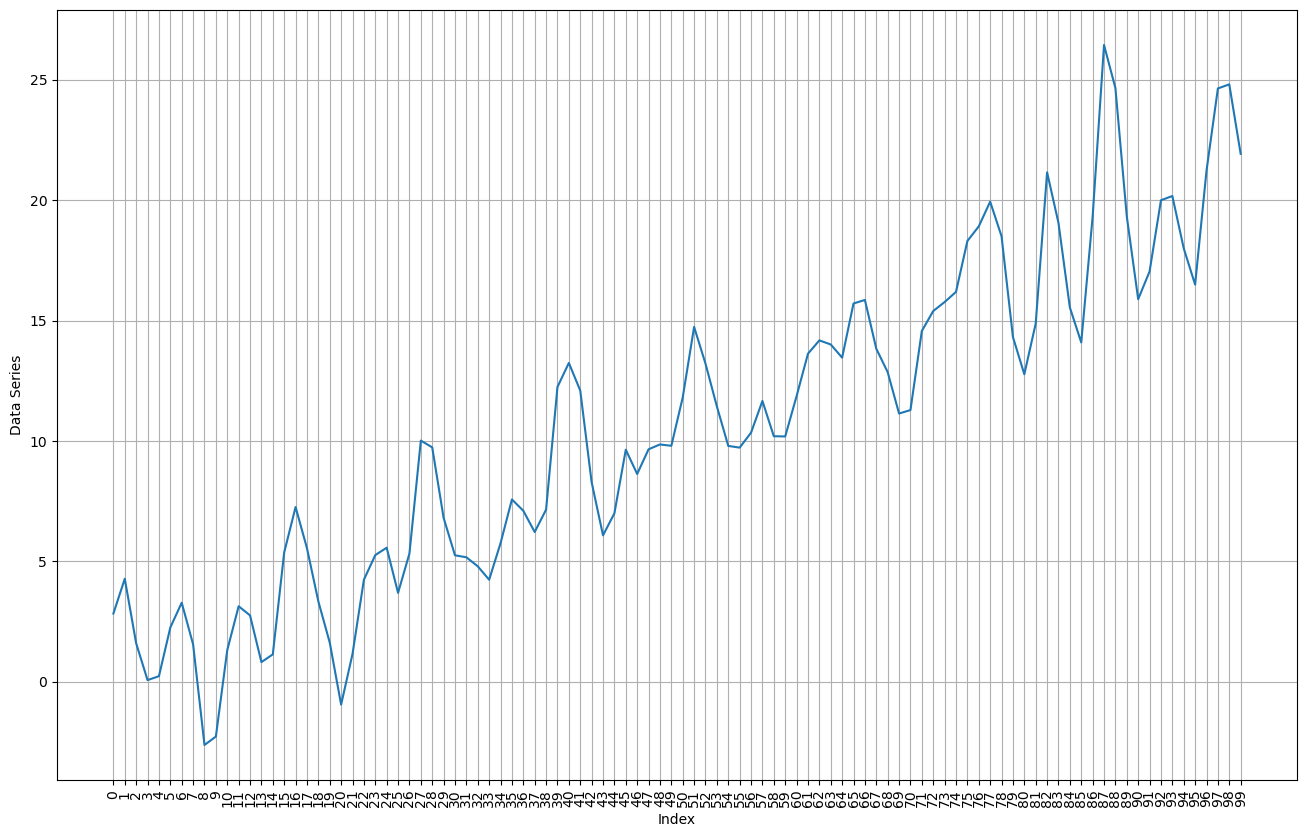

In [4]:
plt.figure(figsize=(16,10))
plt.plot(df.iloc[:100])
plt.grid()
plt.xlabel('Index')
plt.xticks(ticks=df.index[:100], labels=df.index[:100], rotation=90)
plt.ylabel('Data Series')
plt.show()

We can see some seasonality pattern here with rising uptrend. We will make the data stationary first and then try to remove seasonality in this data. The seasonality from the above plot here looks of range 10 or 11 (6,16,27,40).

In [6]:
#checking for null values before moving forward
df.isnull().sum()

Values    0
dtype: int64

## Decomposition of Time Series

We Will decompose the time series into 4 components that is **base line, trend, seasonality, error** , There are two kind of decompositions available that is :- 

1) **Additional Decomposition** - Here the Time series is Base line + Trend + Seasonality + error
2) **Multiplicative Decomposition** - Here the Time series is Base line * Trend * Seasonality * error 

We will first see what kind of time Series data we have before making it stationary 

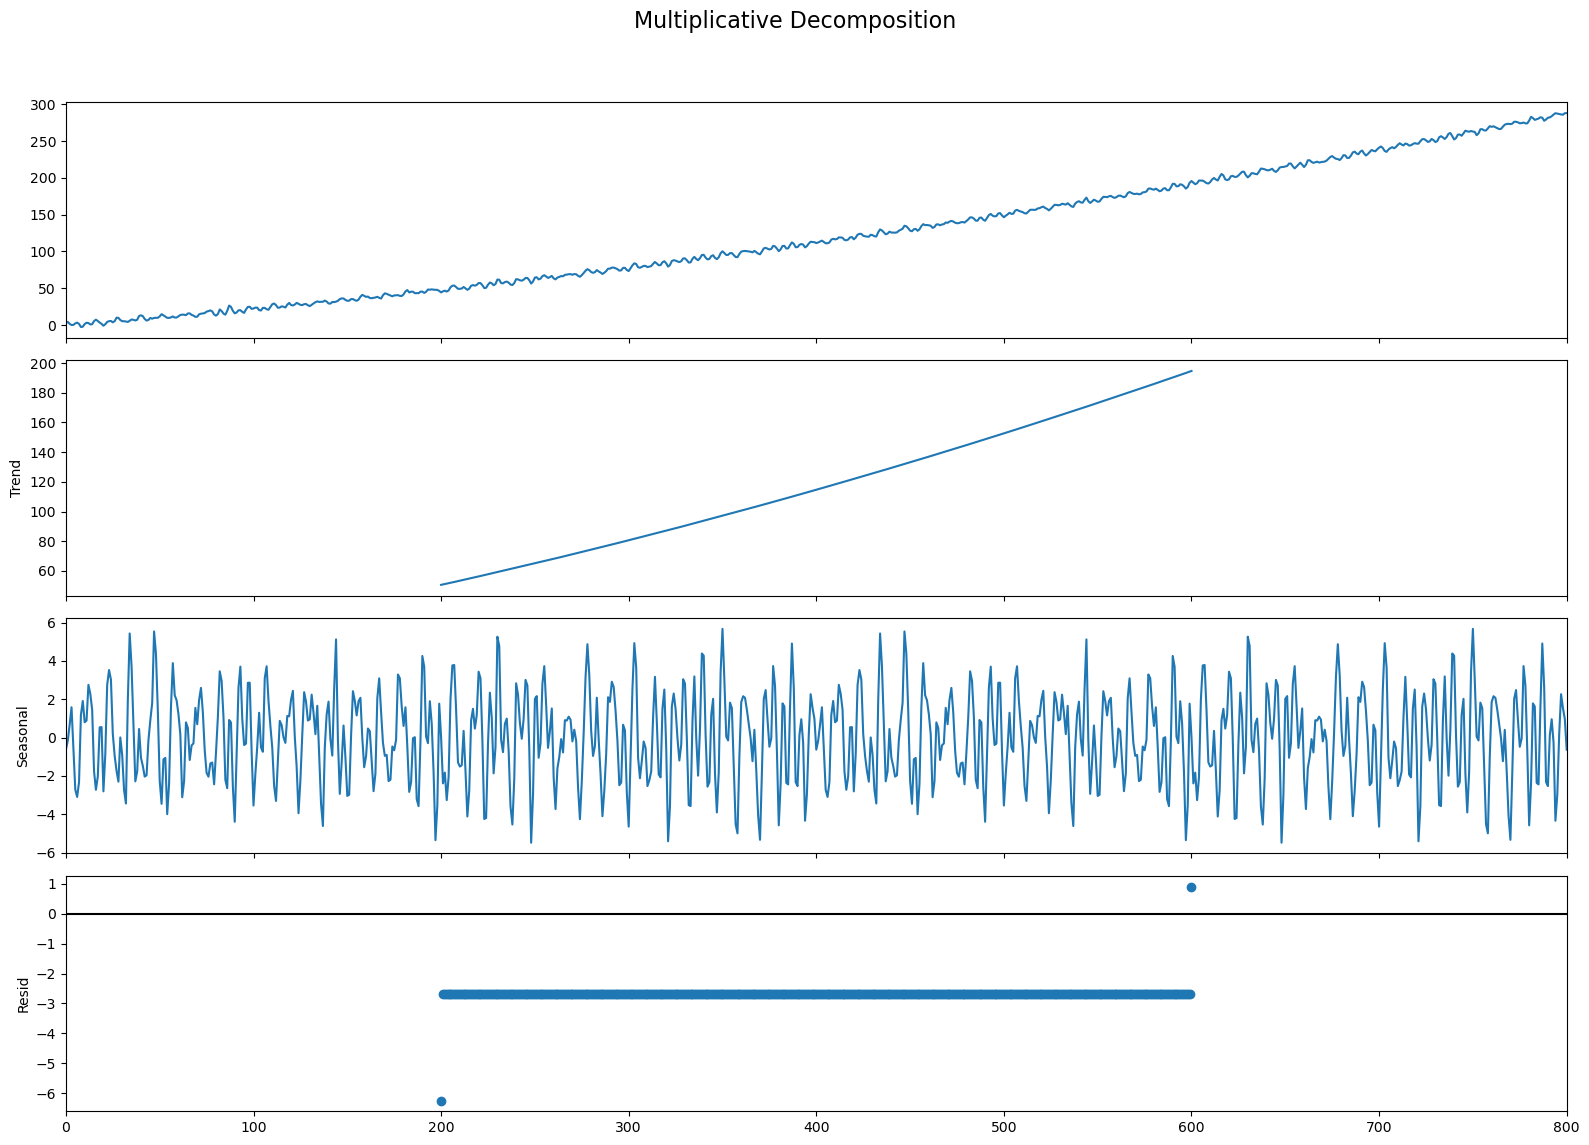

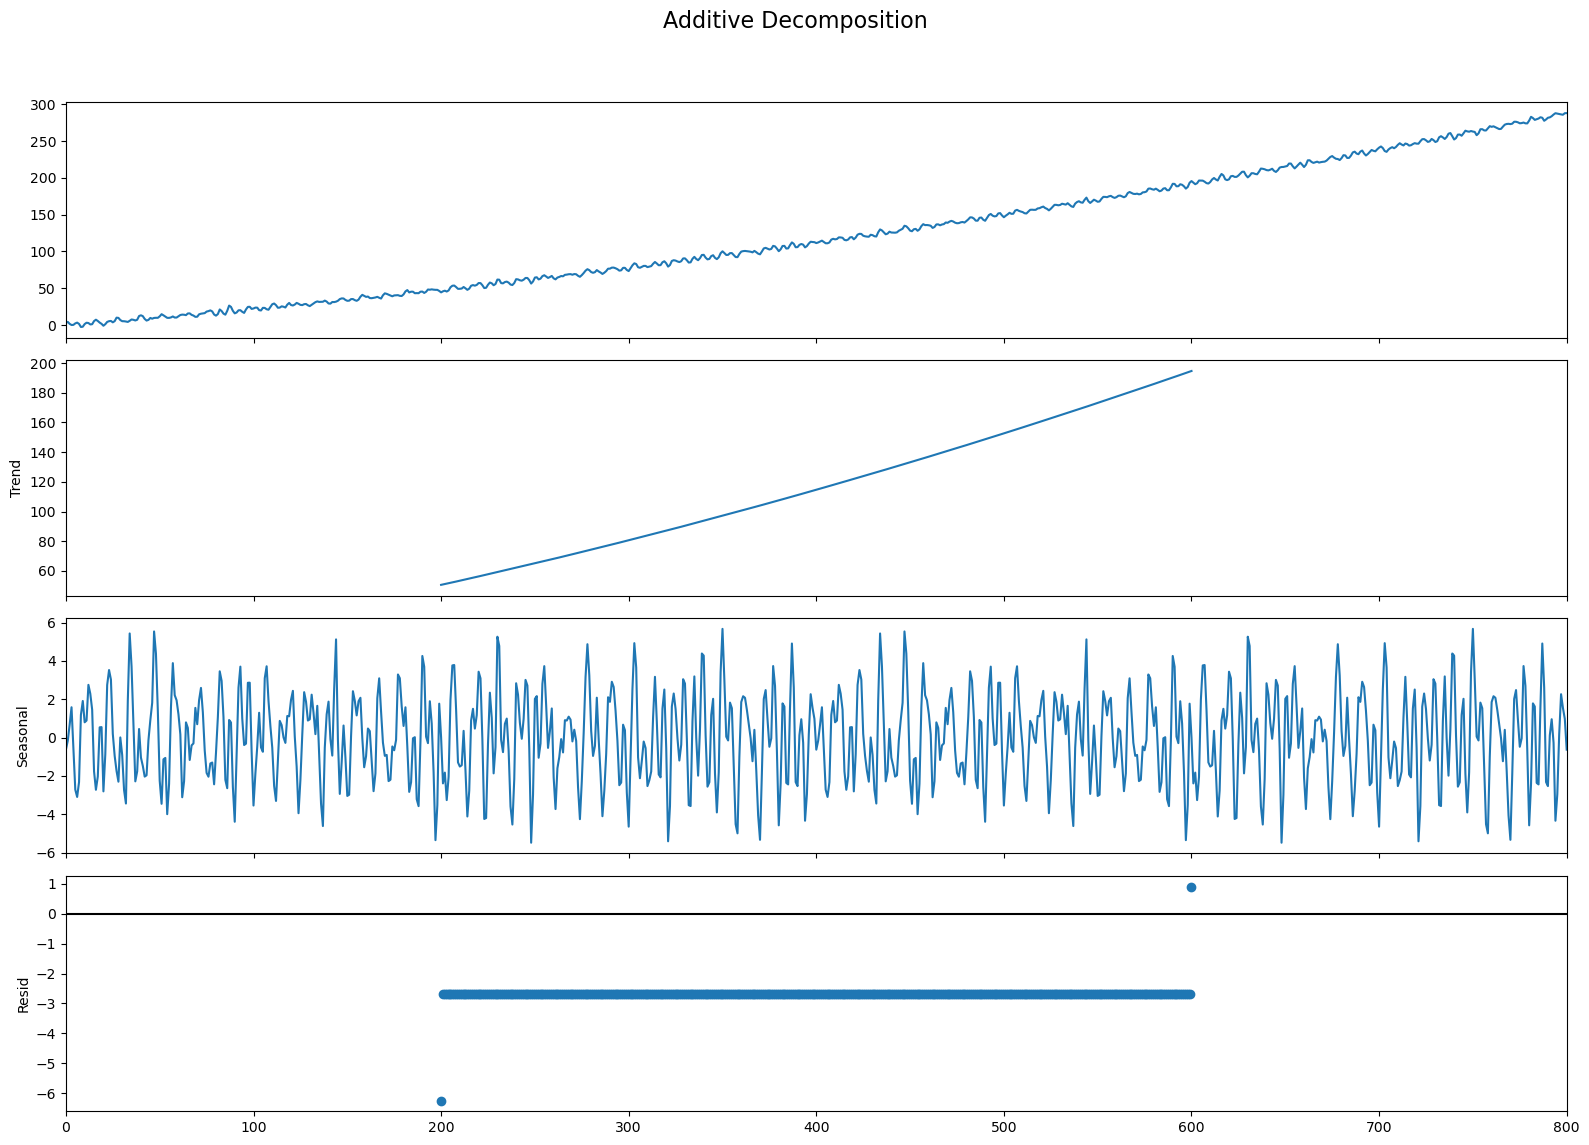

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

multiplicative_decompose = seasonal_decompose(df,model= "Multiplicative",period=400)
additive_decompose = seasonal_decompose(df,model='additive',period = 400)

#plotting
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decompose.plot().suptitle('Multiplicative Decomposition',fontsize = 16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decompose.plot().suptitle('Additive Decomposition',fontsize = 16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Both multiplicative and additive decomposition is giving us some same insgiths, there is a clear uptrend with constant seasonality that is present across the model, we have to detect the seasonality, remove it and then make our data stationary if it is still not stationary. **We choose multiplicative model if the seasonality increases as the seasonal spike increases as our series grows and we use additive model if the seasonal spike remains constant across time series levels** . So we will go with additive Model 

In [18]:
#Train Test Split
k = 0.8
train_size = int(k*len(df))
df_train = df[:train_size]
df_test = df[train_size:]
print("Train Data size:",df_train.size,"Test data size is:",df_test.size)

Train Data size: 640 Test data size is: 161


We Will first make our train data stationary and then proceed with modelling

## Stationarity 

A data is weak stationary is :-

1) The mean is constant across time
2) Variance is constant across time
3) The autocorrelation between X(t) and X(t-h), only depends on h or in stimple words the autocorrelation is constant across time. 

To predict a time series data it should be Stationary, we will use ADF test to predict whether the time series is stationary or not.
In ADF test H0: Time Series has unit roots thus the time series is not stationary, Ha: Time Series is stationary. Therefore if p value is less than significance level (0.05 or 0.01), then we reject null hypothesis and say that our TS is stationary. Another way to reject null hypothesis is if test stat < Critical value

In [19]:
from statsmodels.tsa.stattools import adfuller
def adf_test(df):
    results = adfuller(df)
    return results

Let's first check whether our existing series is stationary or not

In [20]:
stationary_test = adf_test(df_train)
print('ADF Test Statistic',stationary_test[0])
print('ADF p-Value',stationary_test[1])
print('Critical Values',stationary_test[4])

ADF Test Statistic 11.796409924870924
ADF p-Value 1.0
Critical Values {'1%': -3.440856177517568, '5%': -2.86617548304384, '10%': -2.56923863104}


We can see from above that our current data is not stationary.

We Will now make our data stationary using Differencing Method 

In [21]:
def make_data_stationary(df,alpha_value):
    results = adf_test(df)
    p_value = results[1]
    diff = 0
    while p_value > alpha_value:
        df = (df - df.shift(1)).dropna()
        diff = diff + 1 
        results = adf_test(df)
        p_value = results[1]
    
    return df, diff, p_value


The required number of differencing to make the data stationary is 1 The p value of our diffenced data is 0.0035000275906402344


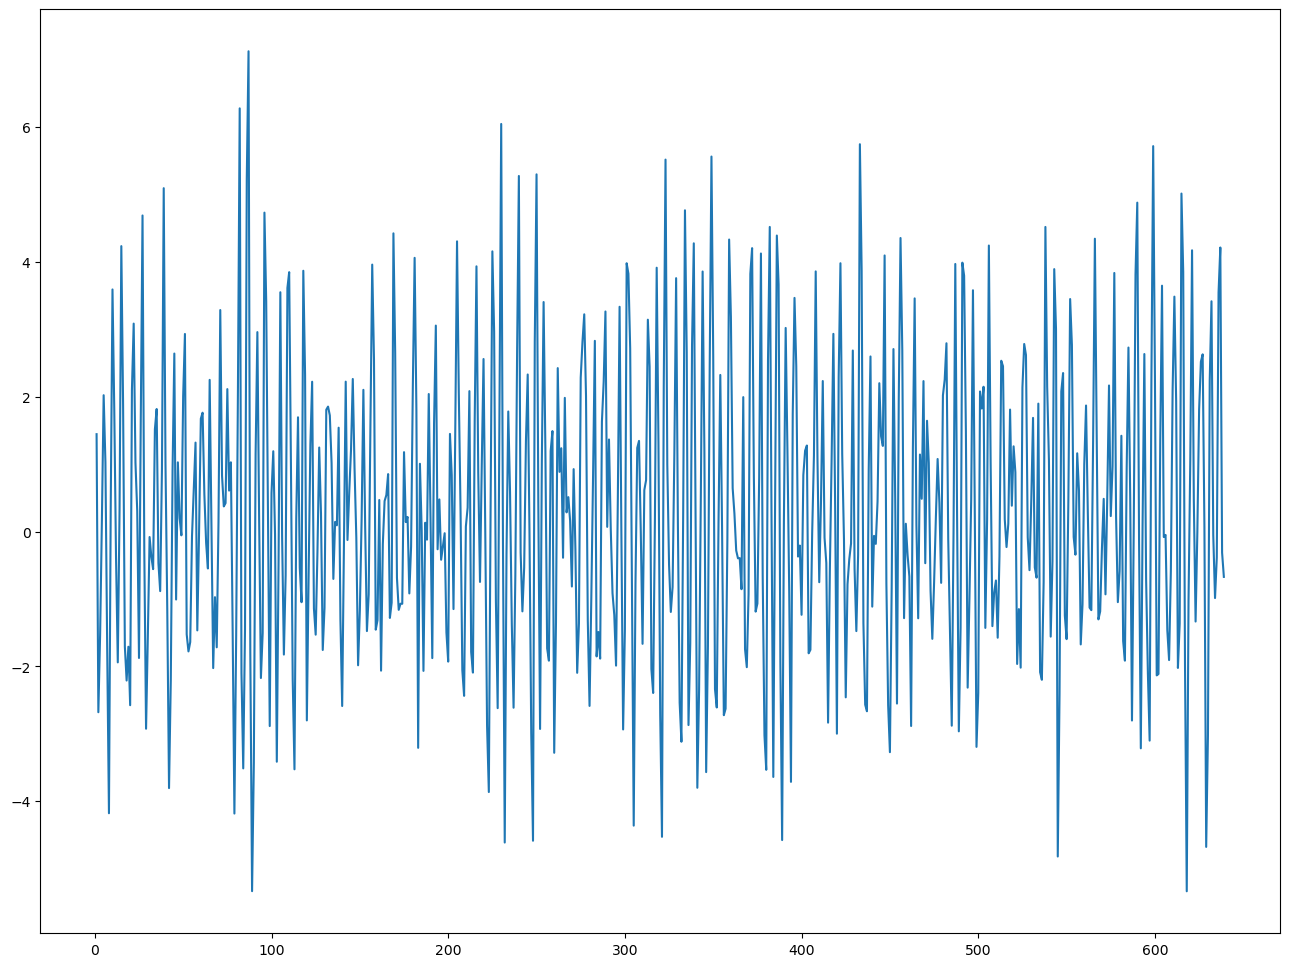

In [22]:
df_stationary,diff,p_value = make_data_stationary(df_train,0.01)
print('The required number of differencing to make the data stationary is',diff, "The p value of our diffenced data is",p_value)
plt.plot(df_stationary)

In [23]:
df_stationary.to_excel('Stationary_data.xlsx',index=False)

We can now see that our data looks stationary, we required 1 differencing and the p value of our differenced value is also less than 0.05 which means we reject null hypothesis of adfuller test and conclude our data is stationary

## Seasonality 

Though our data looks stationary but it is also important to remove seasonality if any present in our data, from the visual inspection we can see some occasional spikes but we are not very sure if these spikes occur at repeated times at fixed interval of time or not. 

We will first plot ACF plot, ACF or autocorrelation function tells us on what lags our current data depends on through direct and indirect correlation

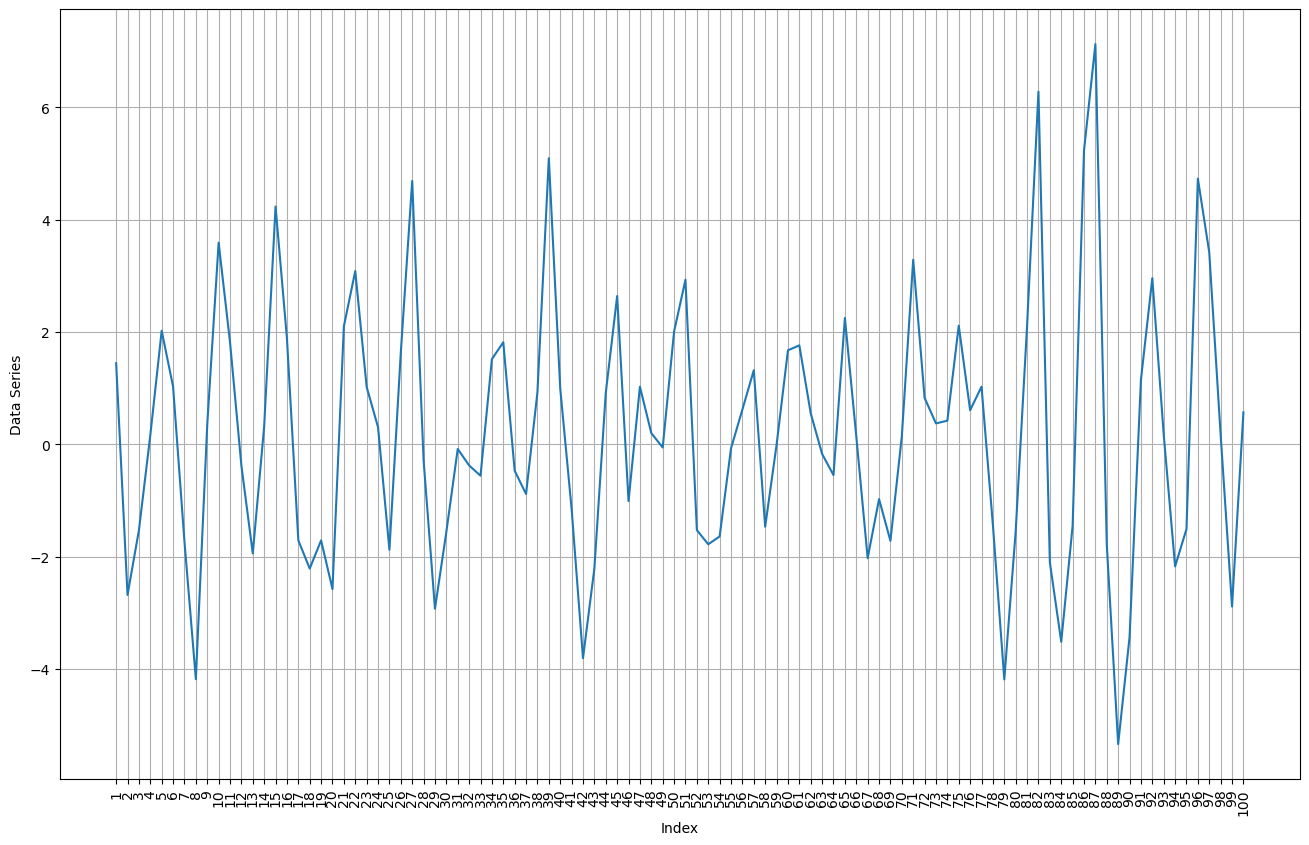

In [24]:
plt.figure(figsize=(16,10))
plt.plot(df_stationary.iloc[:100])
plt.grid()
plt.xlabel('Index')
plt.xticks(ticks=df_stationary.index[:100], labels=df_stationary.index[:100], rotation=90)
plt.ylabel('Data Series')
plt.show()

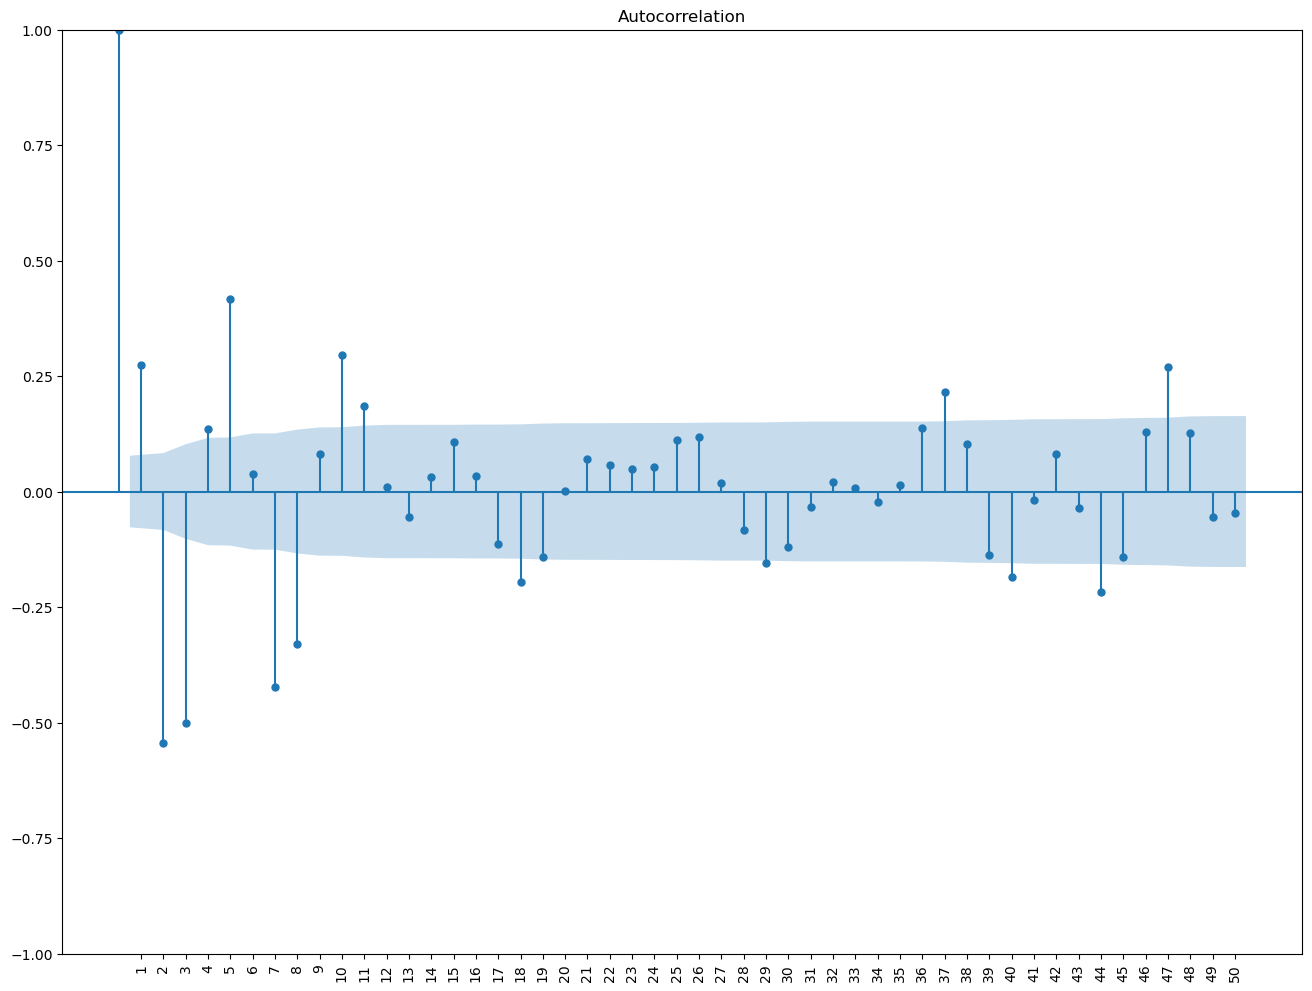

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig = plot_acf(df_stationary,lags = 50)
plt.xticks(ticks=df_stationary.index[:50], labels=df_stationary.index[:50], rotation=90)
plt.show() #Lags shows till how many lags we want to show our ACF plot for

There is no hint from above ACF plot, if there was a very prominent reoccuring seasonality pattern we would have observed spikes at regular interval. Let's see PACF plot as well to see whether we see any reoccuring theme using direct correlation

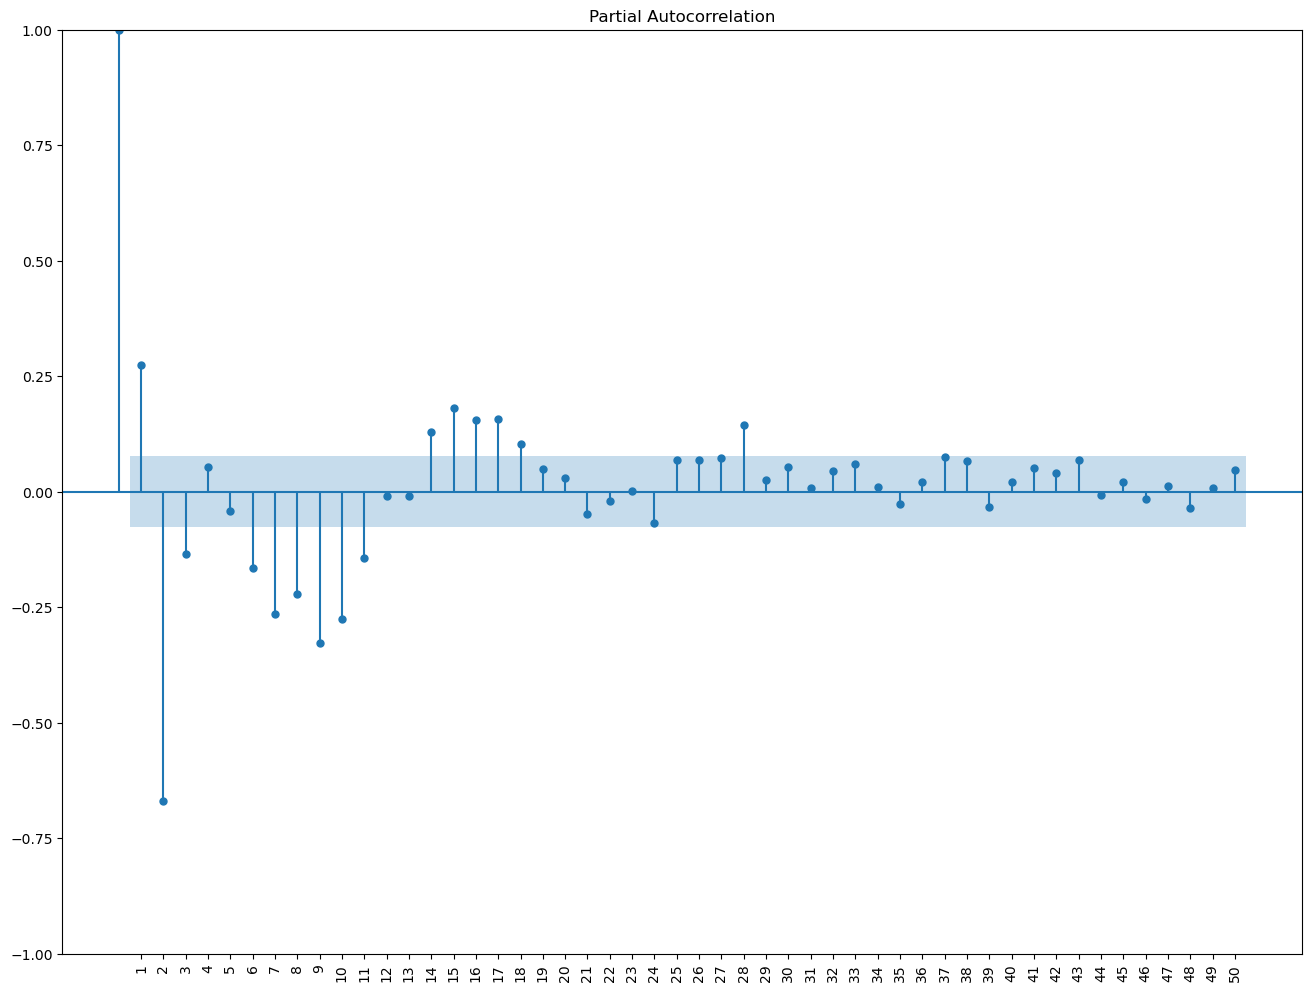

In [26]:
fig = plot_pacf(df_stationary,lags = 50)
plt.xticks(ticks=df_stationary.index[:50], labels=df_stationary.index[:50], rotation=90)
plt.show()

Here also we can't say anything from certainity 

The below is STL decomposition at various lags to check seasonality. The ideal seasonality lag will have clear seasonal pattern in seasonality column and there should be no pattern in residual column

4


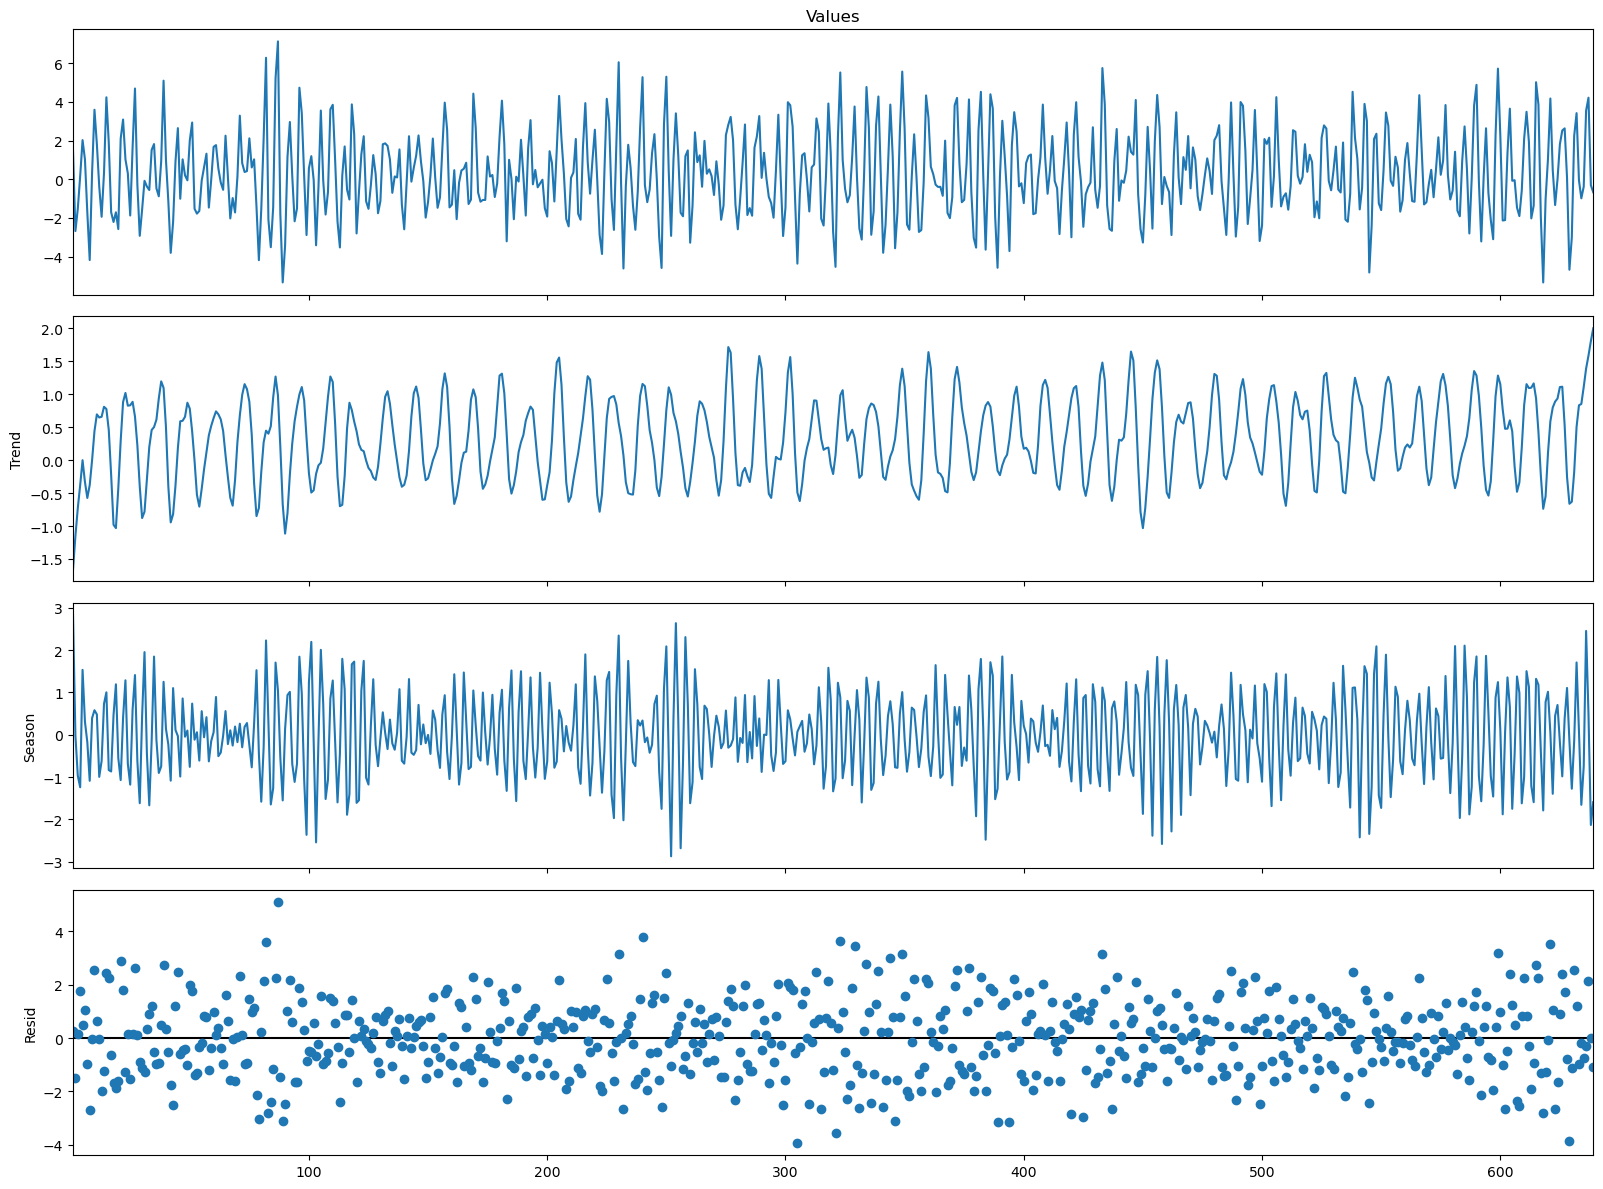

5


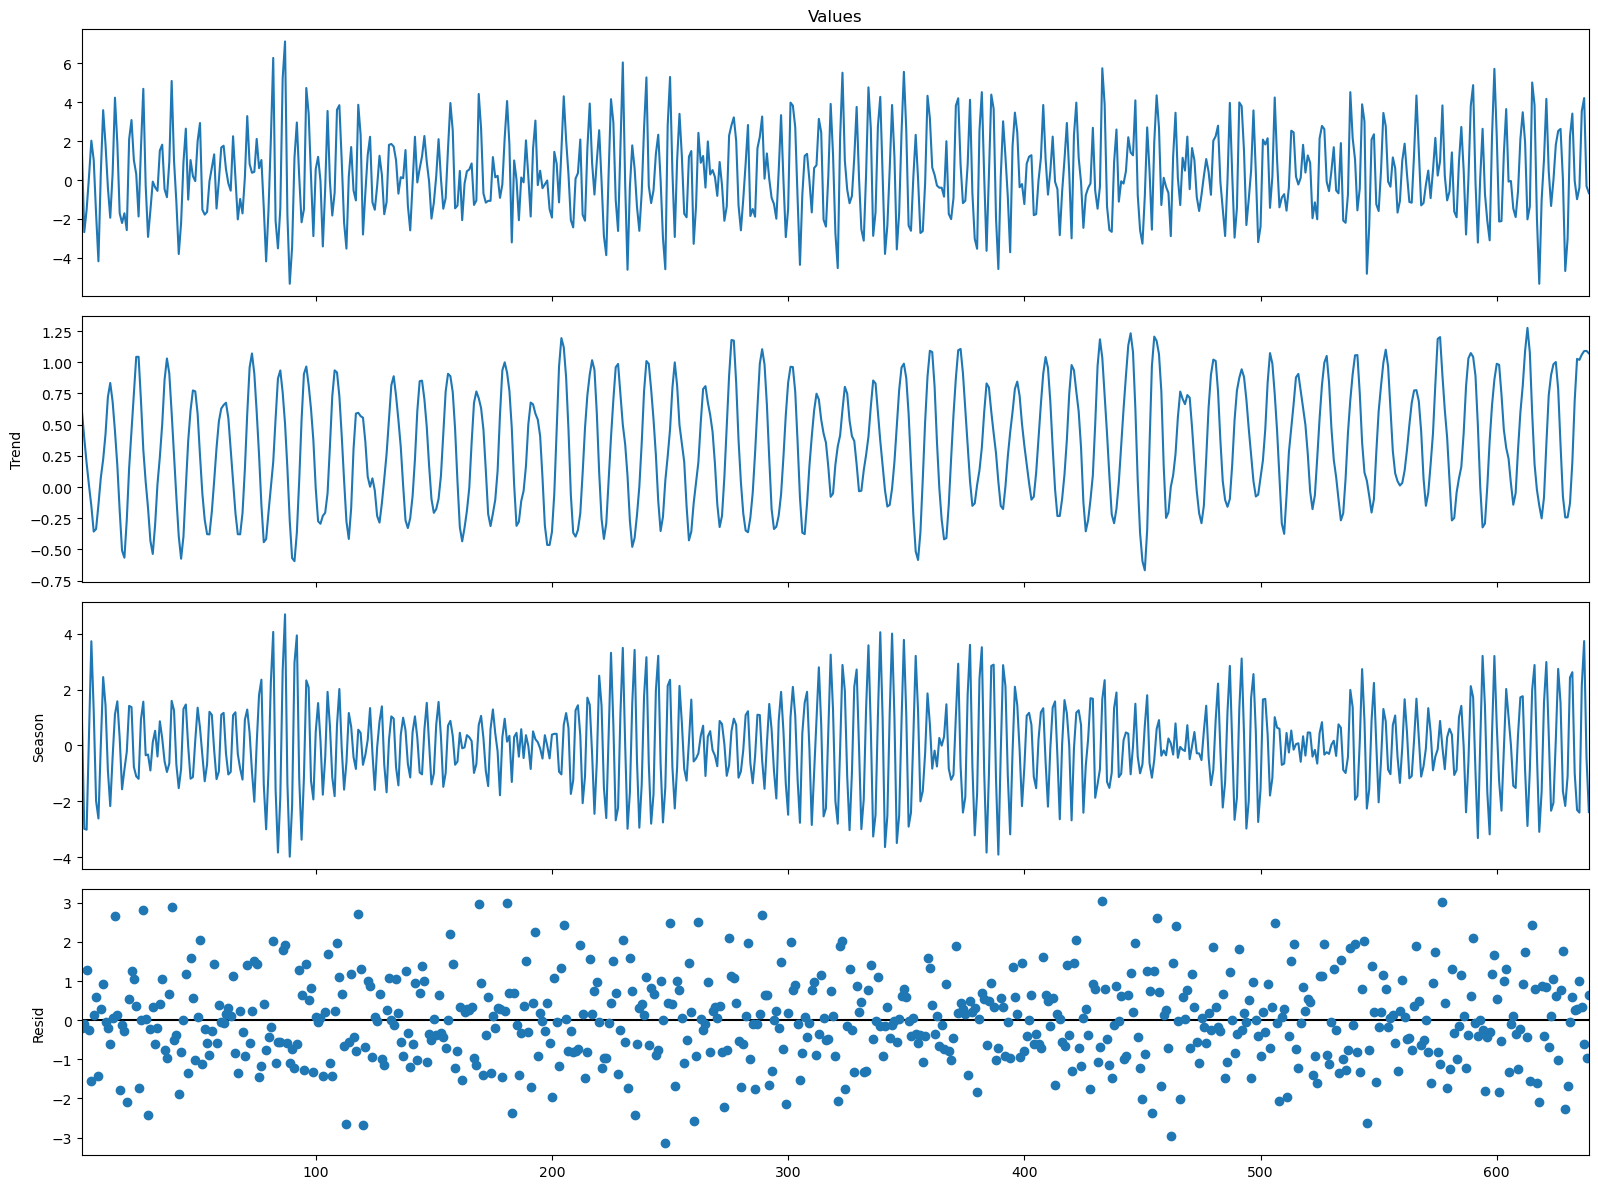

6


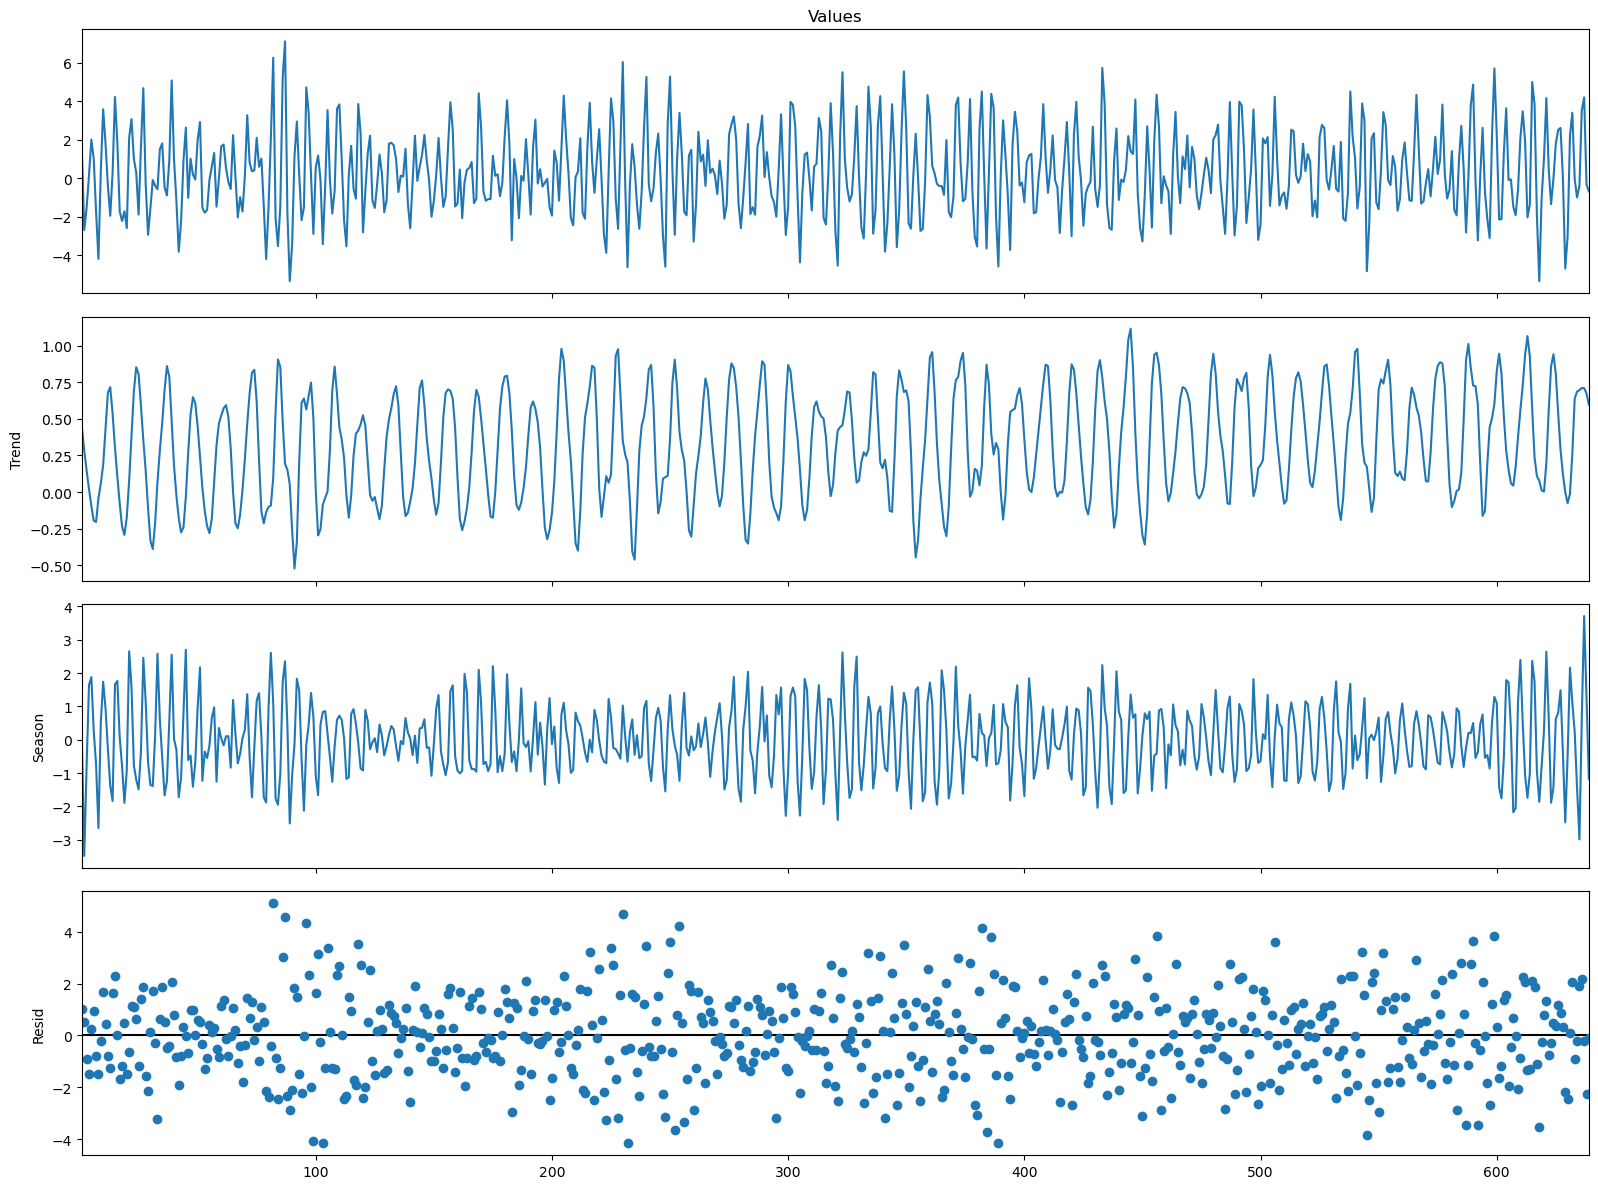

7


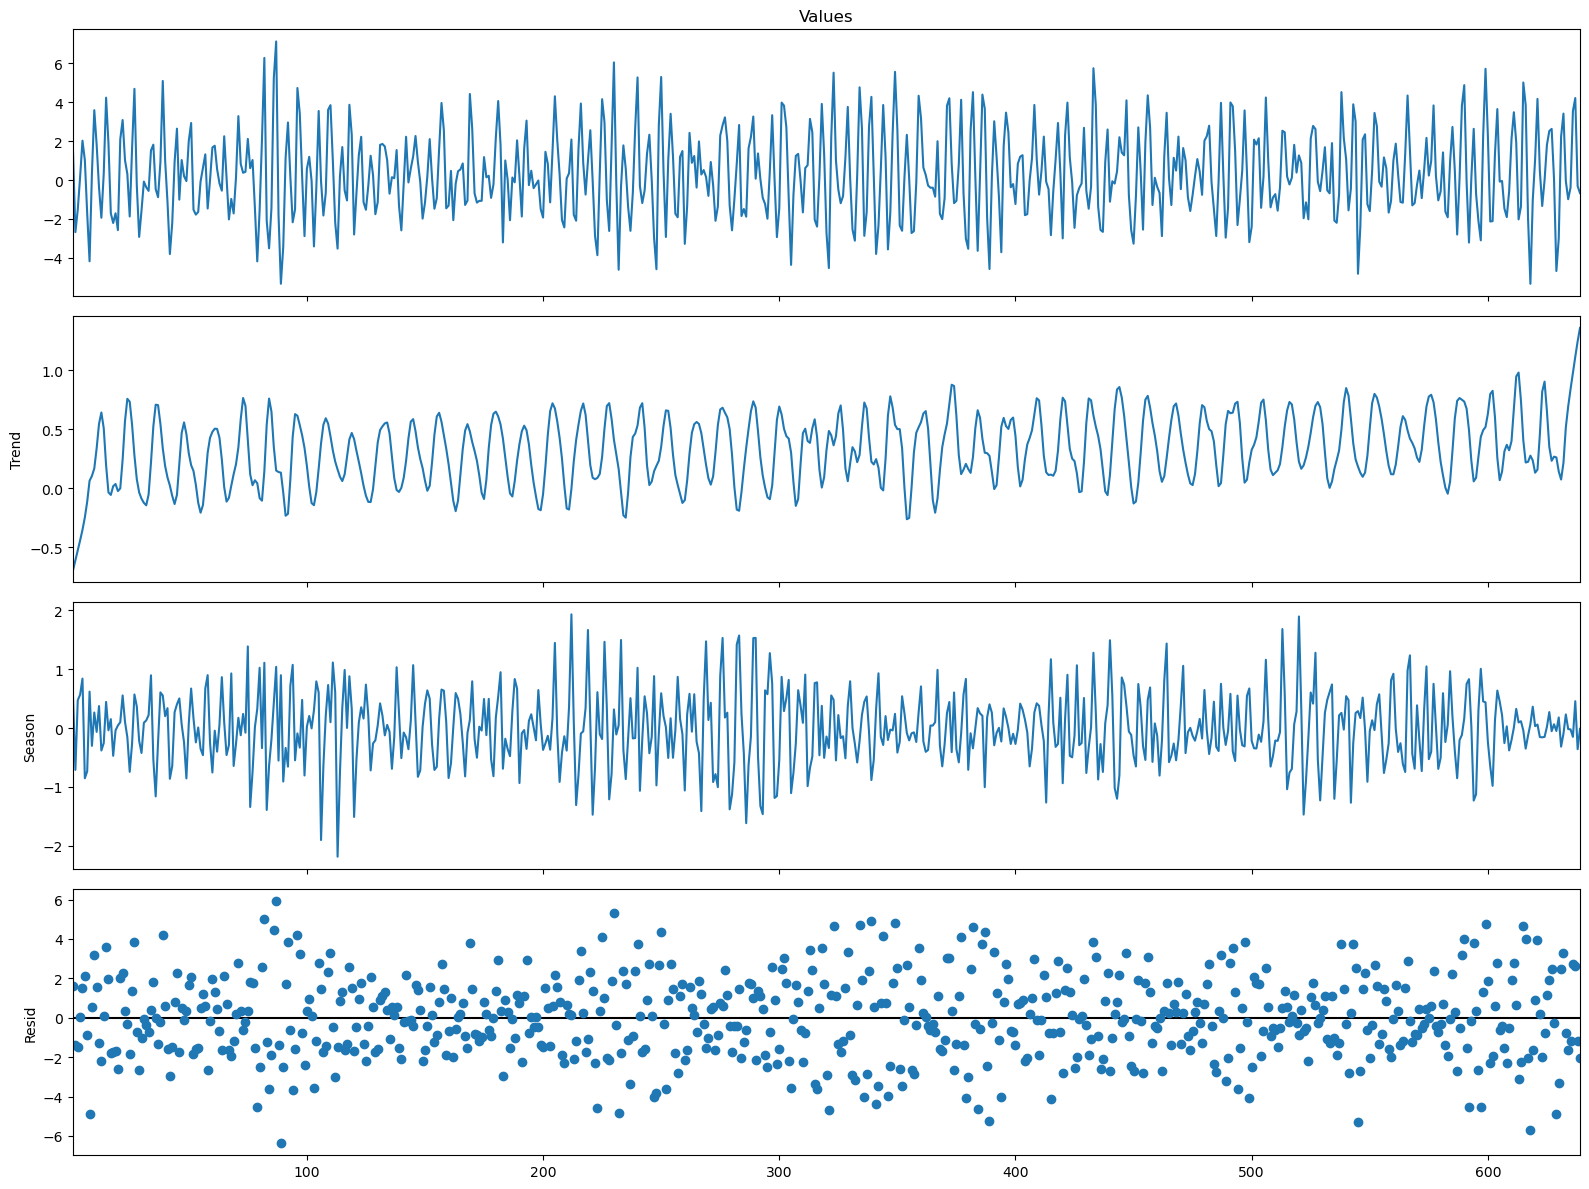

8


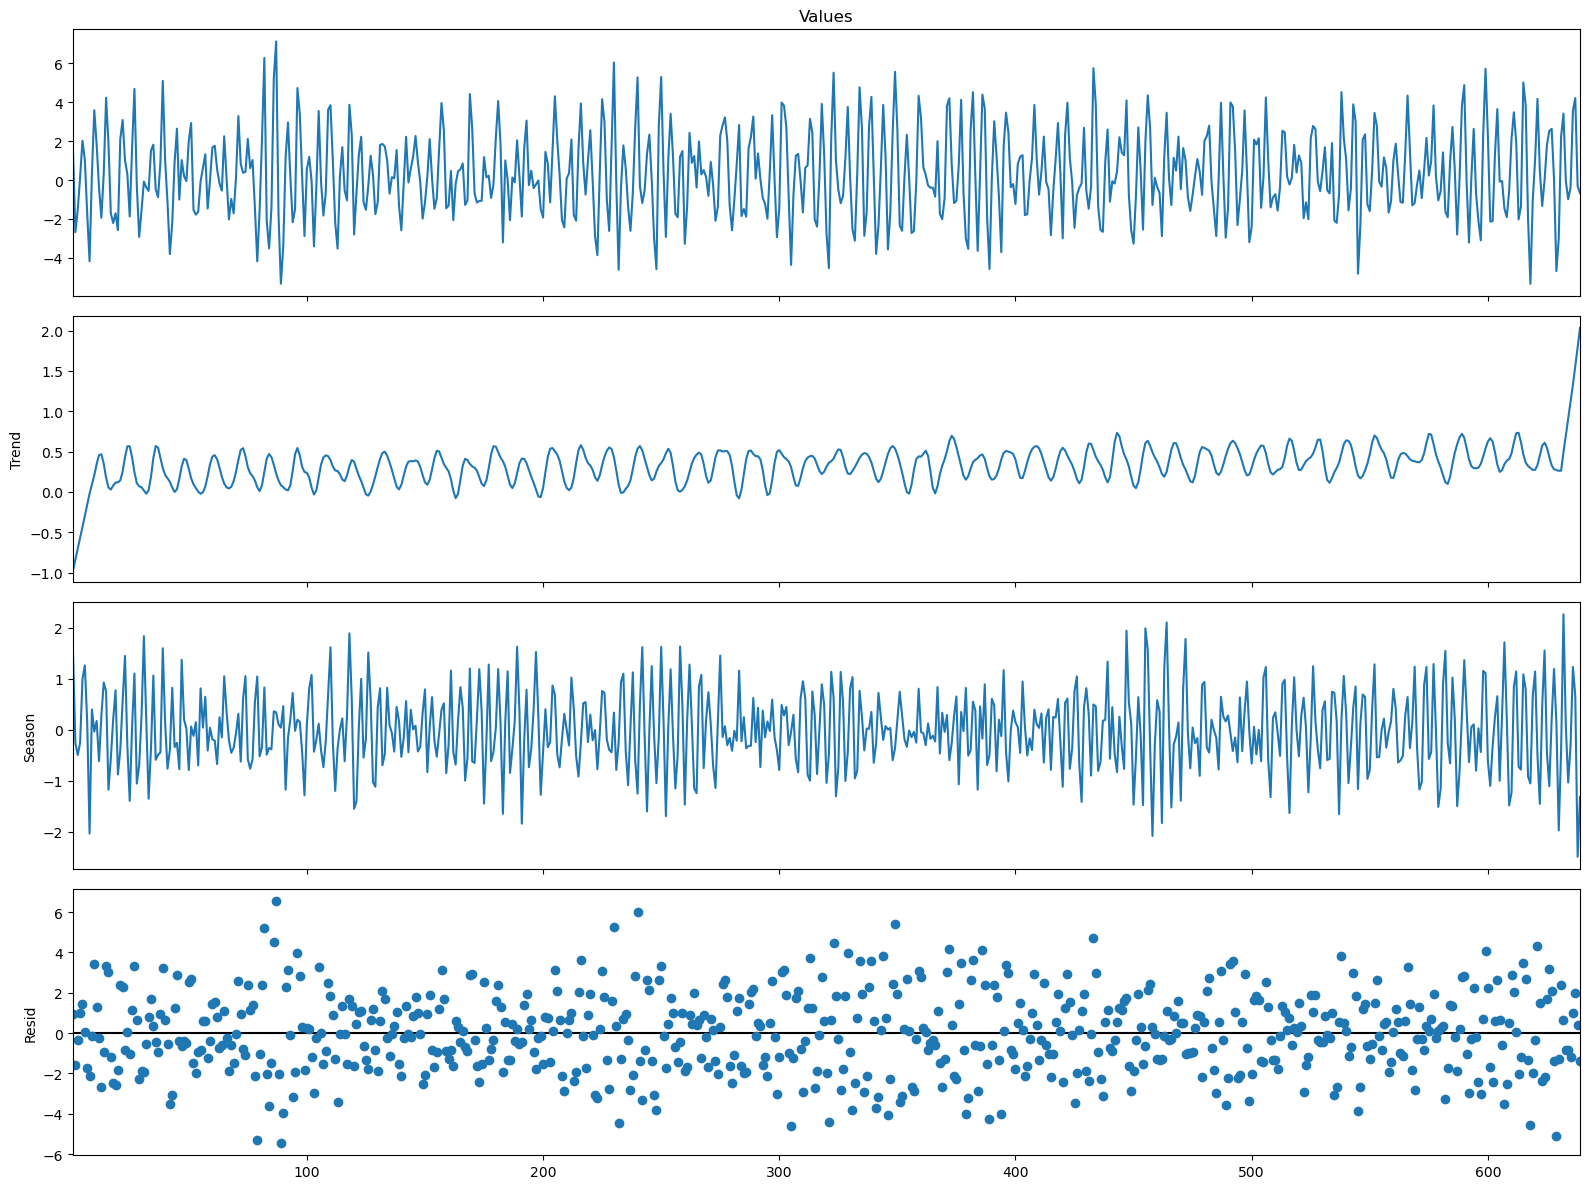

9


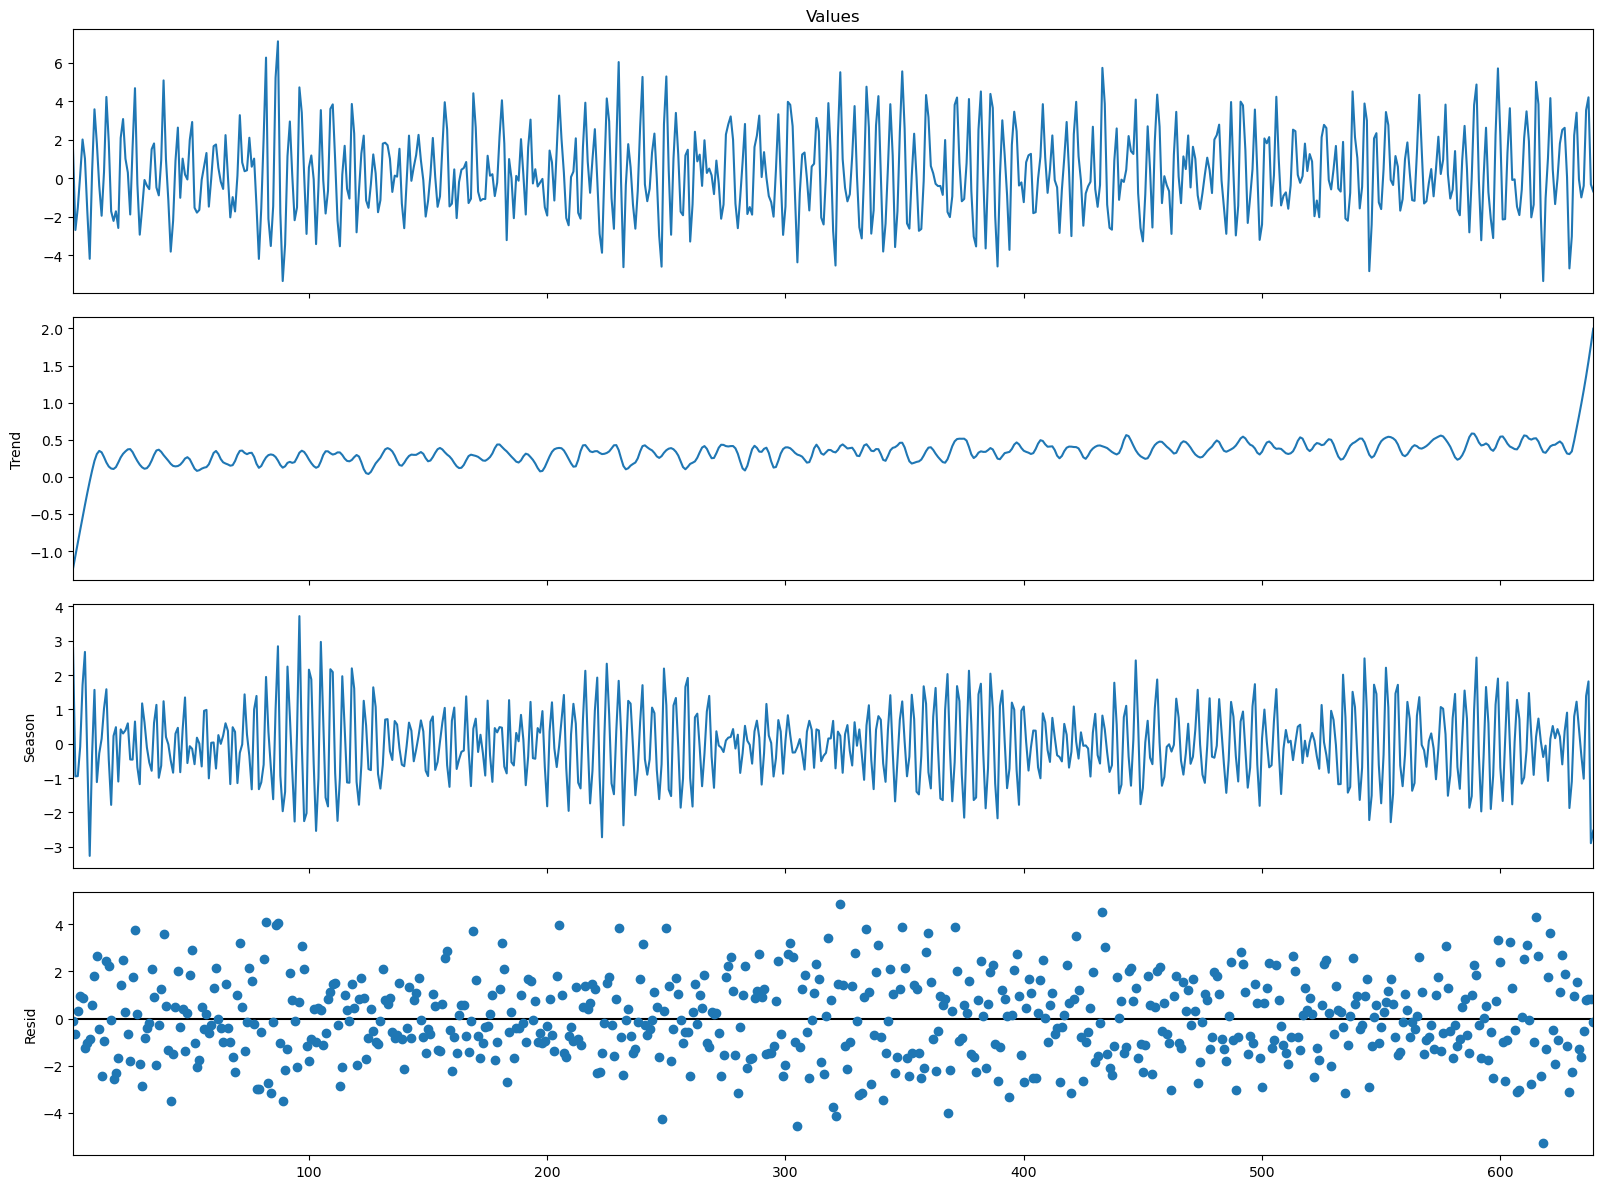

10


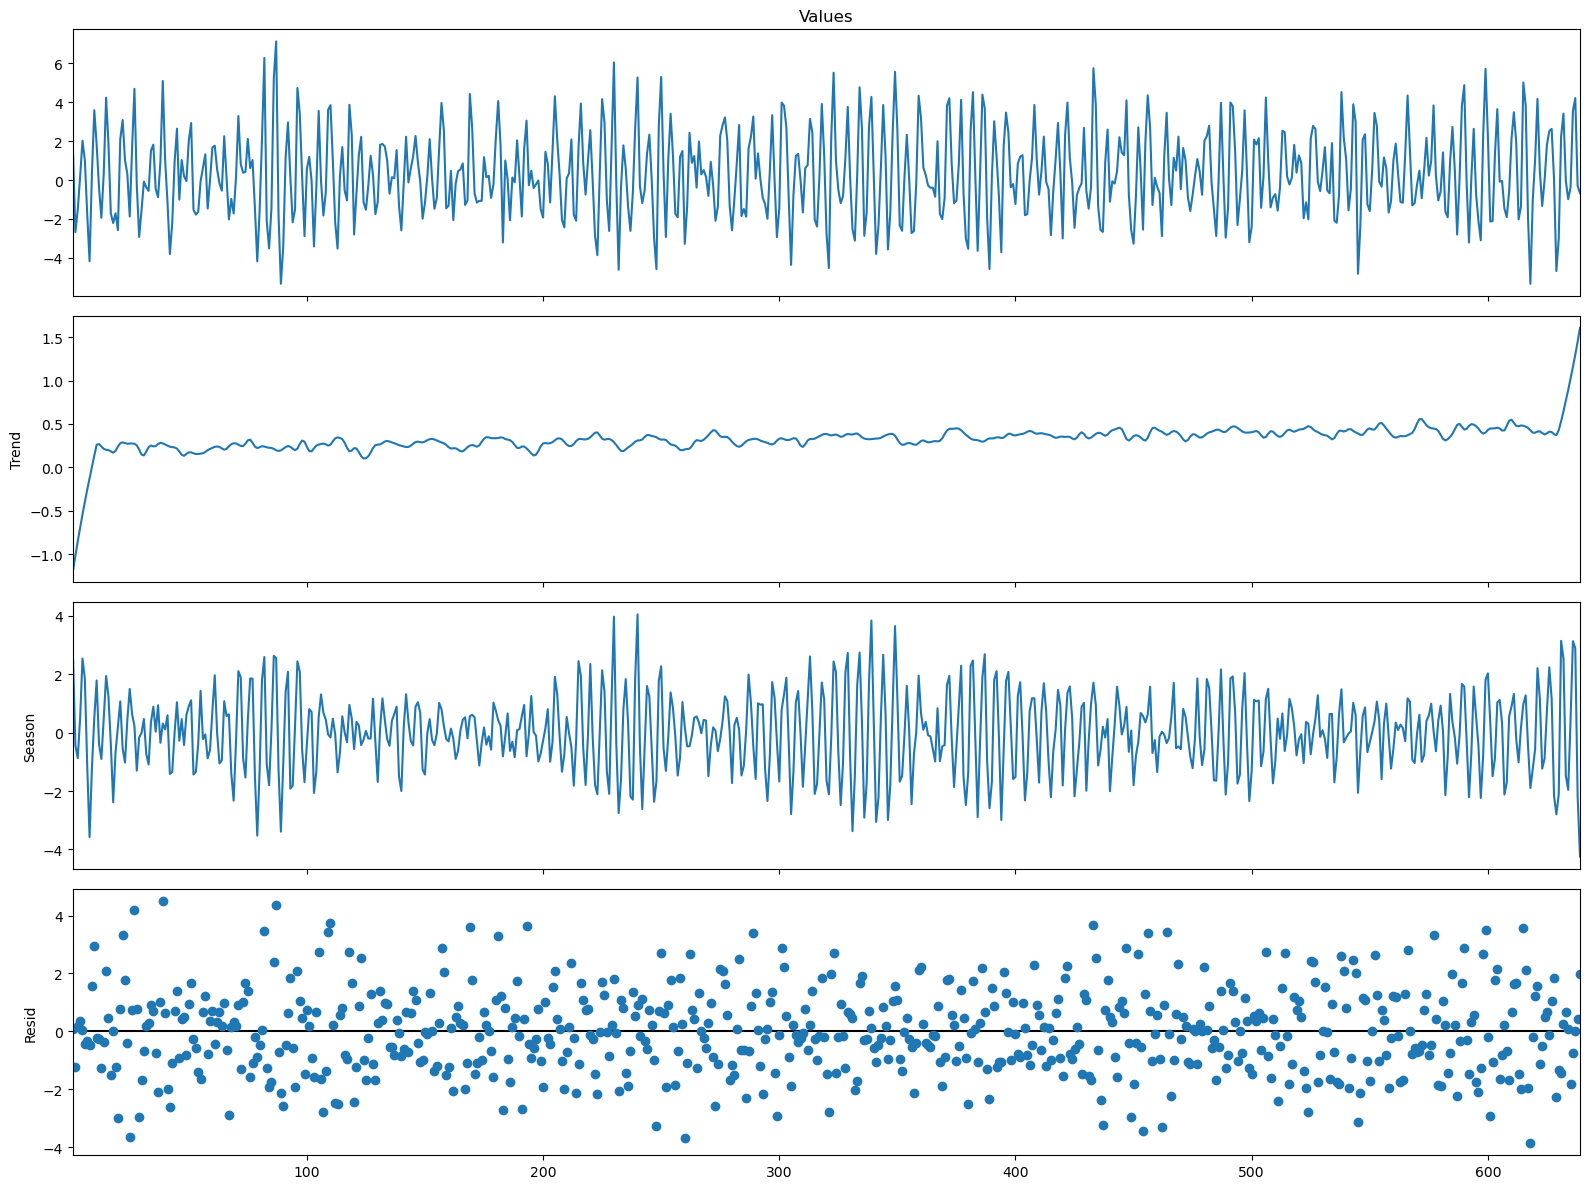

11


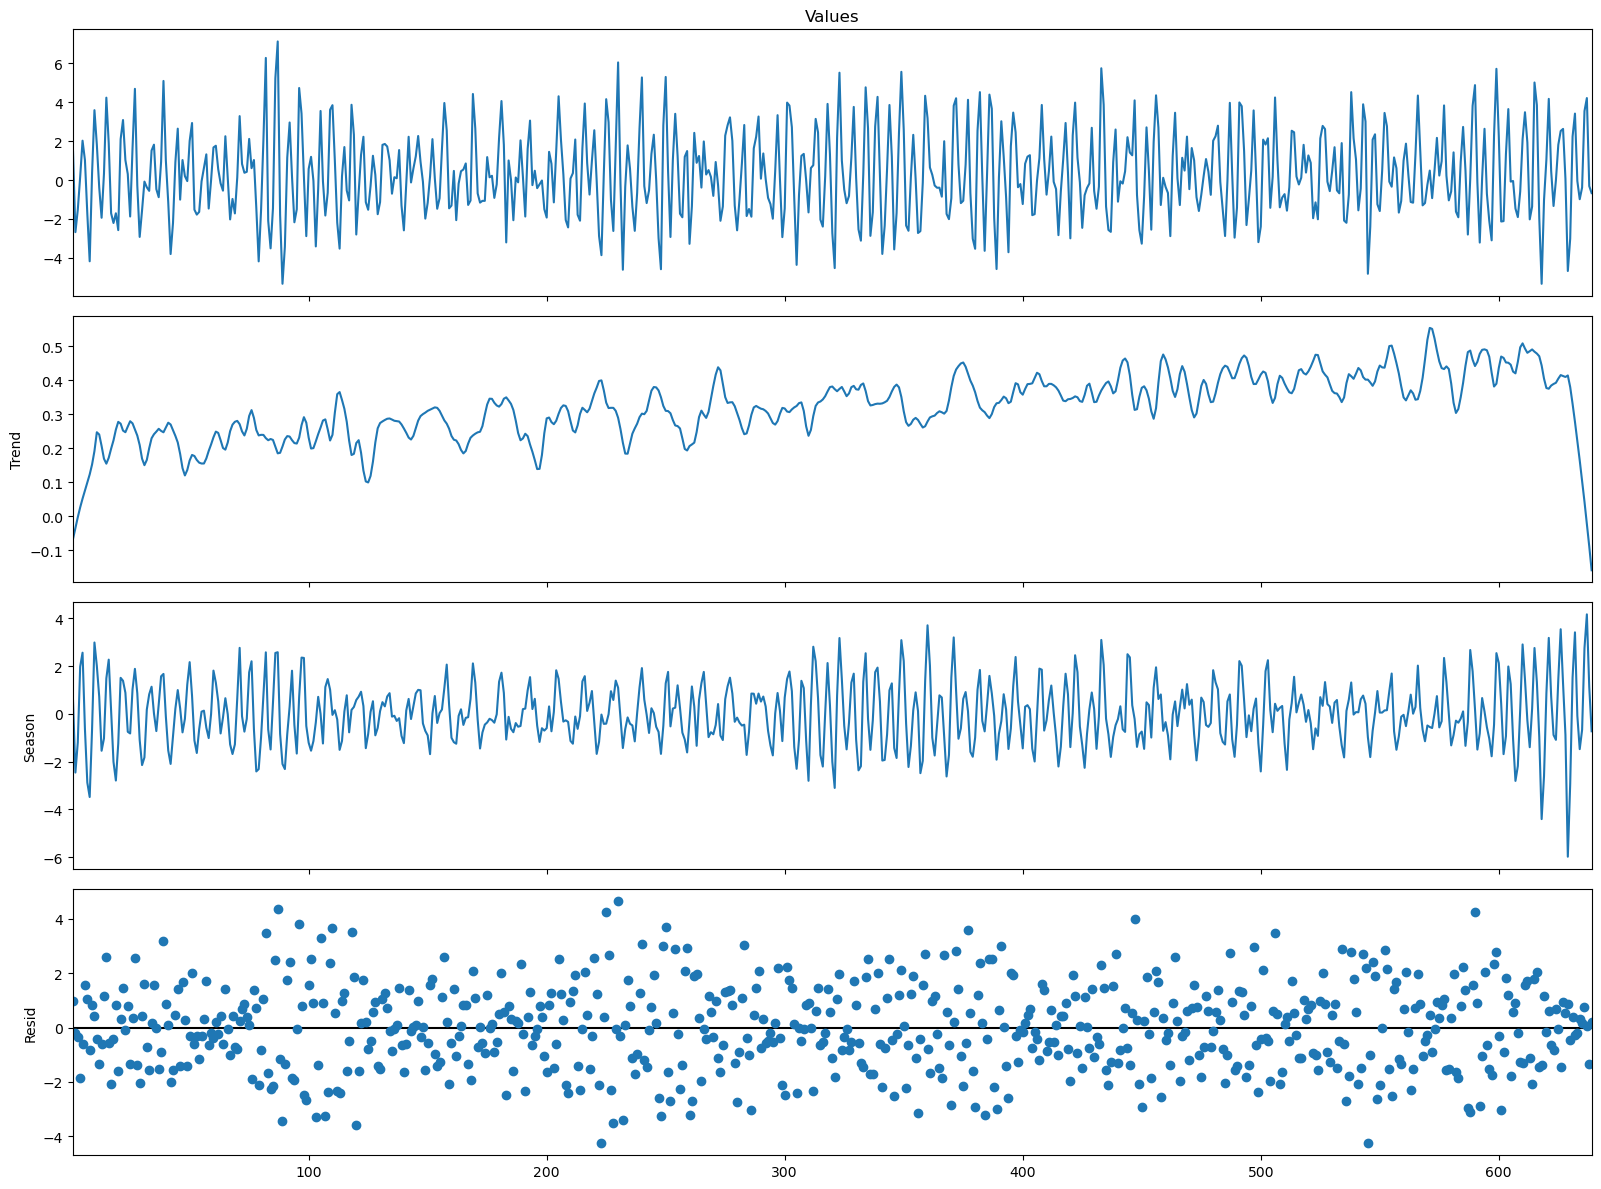

12


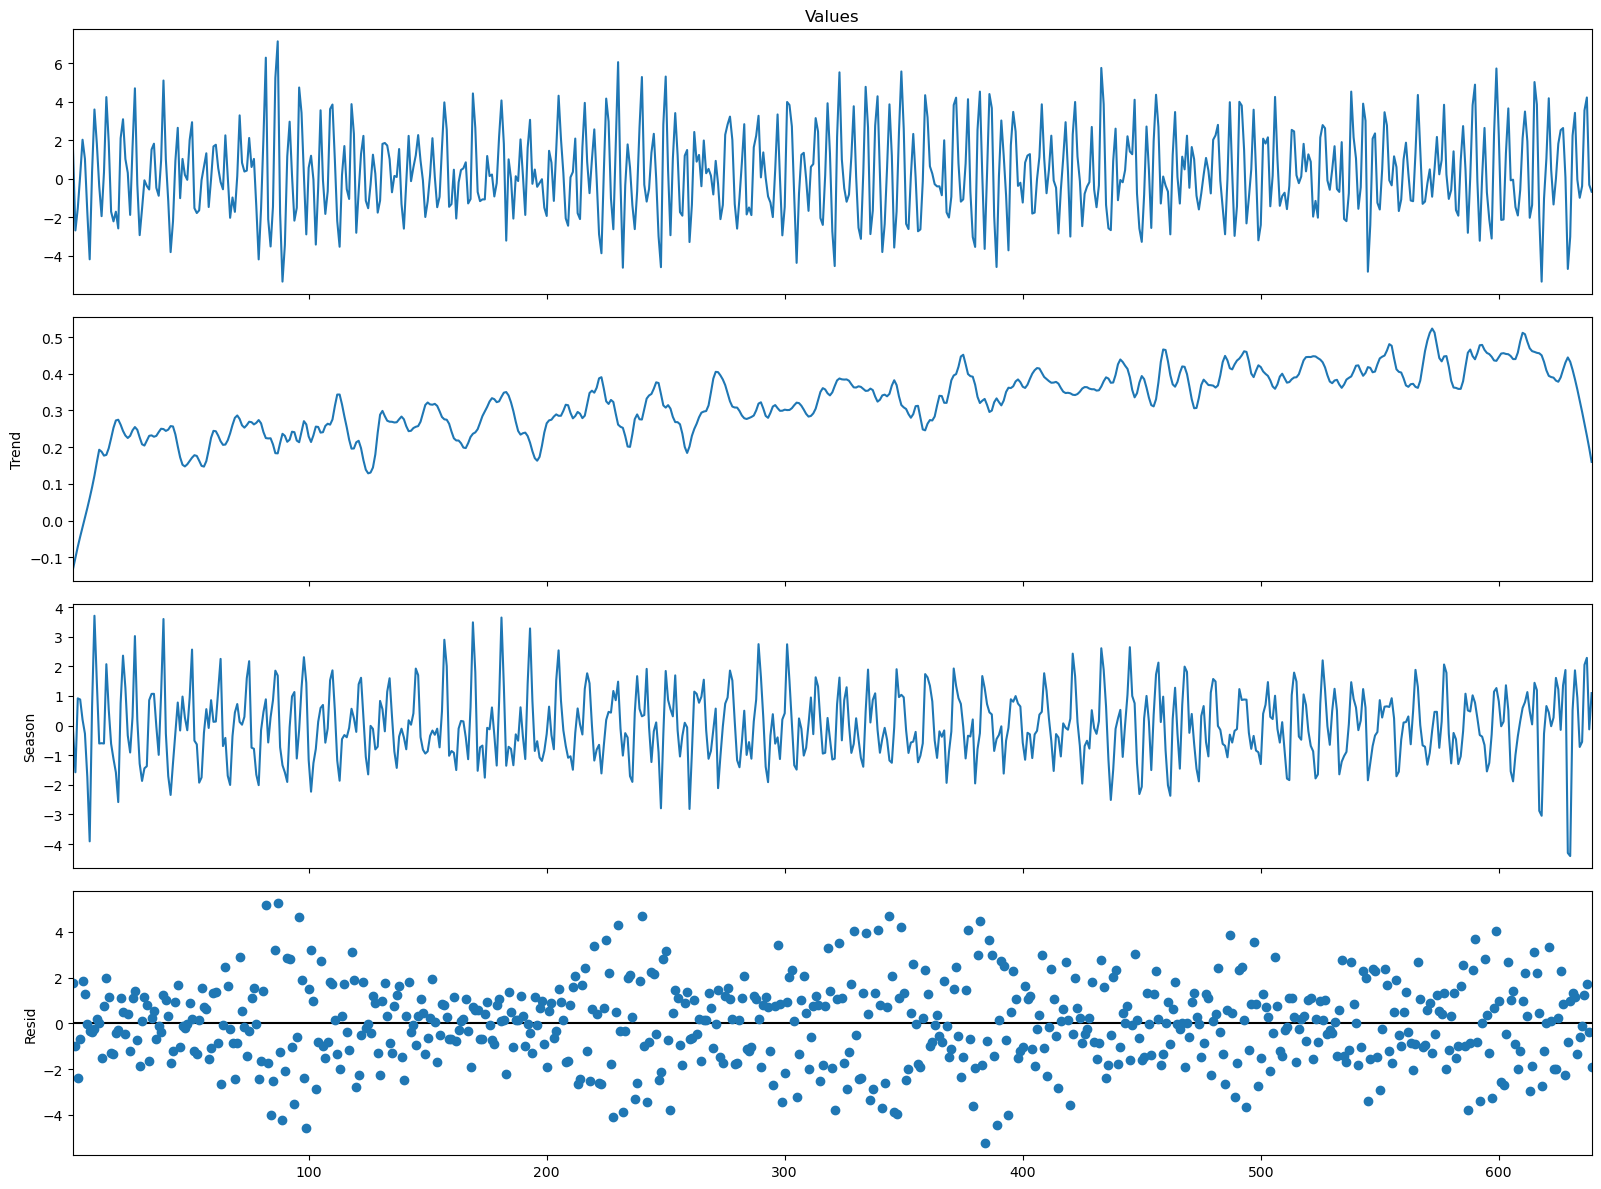

In [29]:
from statsmodels.tsa.seasonal import STL

for i in [4,5,6,7,8,9,10,11,12]:
    print(i)
    stl = STL(df_stationary['Values'],period =i)
    result = stl.fit()
    result.plot()
    plt.show()

From the above STL decomposition the seasonal component at lag 10 looks more prominent as there the trend is getting flat and more data is being captured in seasonal part rather than the trend part. Also with this we don't see any clear pattern in residuals in lag 9 and 10. So in case of perfect reoccuring seasonality We would have seen seasonality pattern in seasonal part, the residuals would not make any patter and the trend should be flat since there is no Trend in the data.

Let us look at fourier transformation to understand seasonality better

Dominant Frequency: 0.1346
Estimated Stationarity Period (in time steps): 7.43


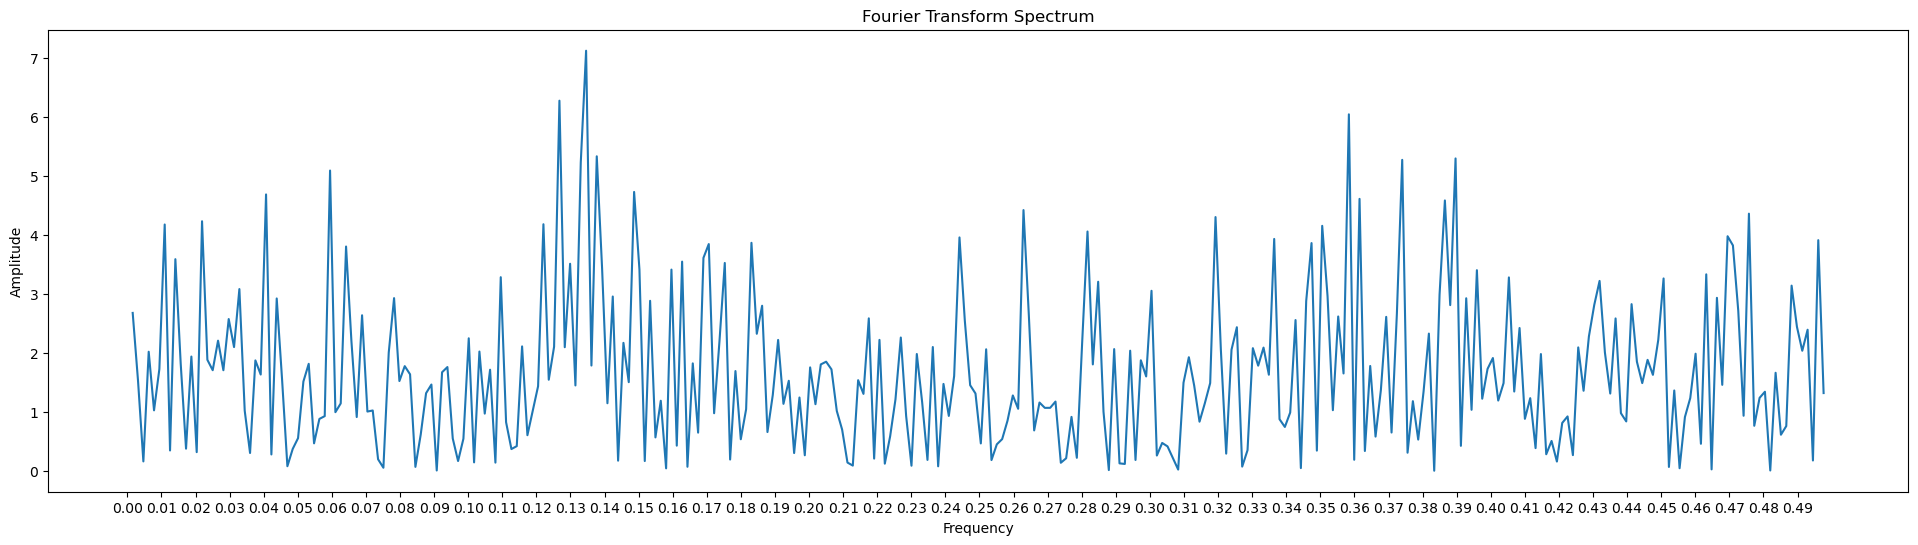

In [32]:
from scipy.fft import fft
f = np.fft.fft(df_stationary)
freq = np.fft.fftfreq(len(df_stationary))

# Consider only the positive half of frequencies (excluding the zero frequency)
positive_freqs = freq[1:len(df_stationary)//2]
positive_amplitudes = np.abs(f)[1:len(df_stationary)//2]

# Find index of the dominant frequency
dominant_idx = np.argmax(positive_amplitudes)

# Extract dominant frequency
dominant_freq = positive_freqs[dominant_idx]

# Convert frequency to period (number of time steps)
stationarity_period = 1 / dominant_freq

# Print the result
print(f"Dominant Frequency: {dominant_freq:.4f}")
print(f"Estimated Stationarity Period (in time steps): {stationarity_period:.2f}")

plt.figure(figsize=(24,6))
plt.plot(freq[1:len(df_stationary)//2], np.abs(f)[1:len(df_stationary)//2])
plt.title("Fourier Transform Spectrum")
plt.xlabel("Frequency")
plt.xticks(np.arange(0,0.5,0.01))
plt.ylabel("Amplitude")
plt.show()

So FFT decomposes your time series into sum of sine and cosine waves of different frequencies. Here Period = 1/Frequency, therefore each frequency just tells you how strong your periodic component is. For eg the max value of frequency is around 0.14 Period = 1/0.145 which is equal to 7.4 or approximately 7 days. It essentially tells you how strong each periodic component is since each frequency gives a periodic component (period might be 1day, 2 days, 7 days depending on what frequency you take).

We see a seasonal amplitude around 7.5 and in TSA plot also we can see some seasonality pattern around 8. **Therefore we will test our models with seasonality of 7 because we can't take confirmed results from anything else
Let's see Seasonal trend decomposition as well to gauge whether there is seasonality in our data

In [237]:
df_seasonal_5 = df_stationary - df_stationary.shift(5)
df_seasonal_5 = df_seasonal_5.dropna()
df_seasonal_7 = df_stationary - df_stationary.shift(5)
df_seasonal_7 = df_seasonal_7.dropna()
df_seasonal_8 = df_stationary - df_stationary.shift(8)
df_seasonal_8 = df_seasonal_8.dropna()
df_seasonal_9 = df_stationary - df_stationary.shift(9)
df_seasonal_9 = df_seasonal_9.dropna()
df_seasonal_10 = df_stationary - df_stationary.shift(10)
df_seasonal_10 = df_seasonal_10.dropna()
df_seasonal_11 = df_stationary - df_stationary.shift(11)
df_seasonal_11 = df_seasonal_11.dropna()
df_seasonal_12 = df_stationary - df_stationary.shift(12)
df_seasonal_12 = df_seasonal_12.dropna()
df_seasonal_13 = df_stationary - df_stationary.shift(13)
df_seasonal_13 = df_seasonal_13.dropna()

**We have reitrated this notebook with multiple seasonalities, turns out seasonality of 10 and 11 was giving the best results and proper fit, so we can safely ignore the results generated by FFT and focus more on visual plots.** We will proceed with the seasonality of 11

## **AR Model** 
AR or autoregressive model means the current value of time series depends on it's Lag, it is generally in form of AR(p) where p depicts number of lags. The optimal number of p in AR model is determined by PACF plot, we will make the PACF plot below to check the optimal number of p

([<matplotlib.axis.XTick at 0x14db9d890>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23'),
  Text(24, 0, '24'),
  Text(25, 0, '25')])

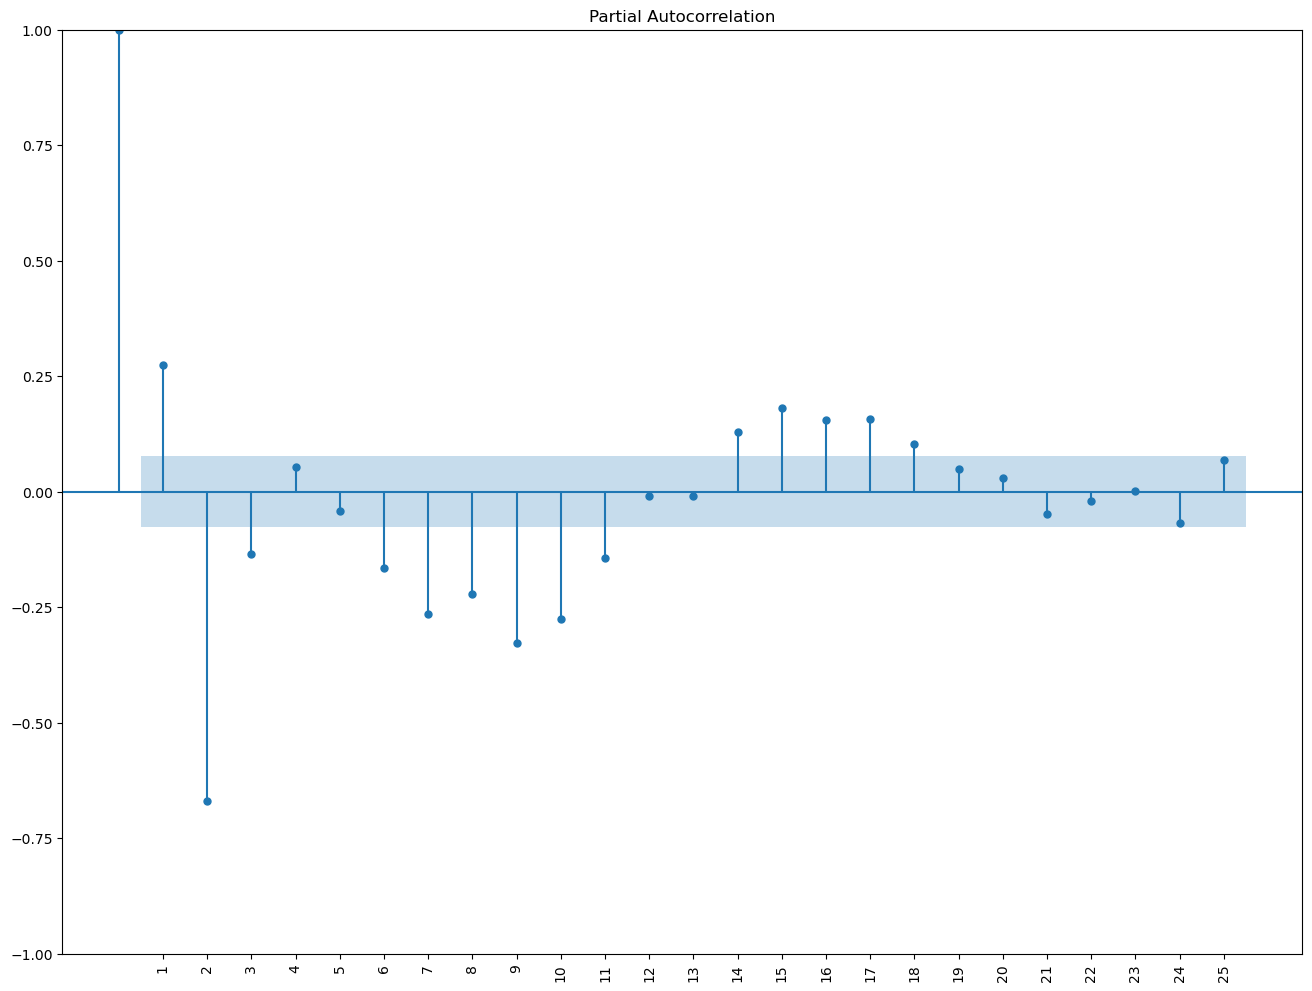

In [286]:
from statsmodels.graphics.tsaplots import plot_pacf
fig = plot_pacf(df_stationary['Values'],lags = 25)
plt.xticks(ticks=df_stationary.index[:25], labels=df_stationary.index[:25], rotation=90)

PACF plots direct correlation between current value and the lag and does not include the indirect correlation like the ACF plot. To find p we will plot PACF of our stationary data and not the seaonality data as plotting the PACF of seasonly differenced data will give us "P" (seasonality P) and not "p", differenced p. From here we can see that our p is 3 as correlation significantly drops after =3

In [291]:
from statsmodels.tsa.arima.model import ARIMA
ar_model = ARIMA(df_seasonal_11,order=(3,0,0))
ar_model = ar_model.fit()
ar_model.summary()

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Values   No. Observations:                  628
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1254.481
Date:                Mon, 14 Jul 2025   AIC                           2518.961
Time:                        20:32:29   BIC                           2541.174
Sample:                             0   HQIC                          2527.590
                                - 628                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0076      0.037      0.208      0.835      -0.064       0.079
ar.L1          0.0090      0.041      0.221      0.825      -0.071       0.088
ar.L2         -0.6361      0.028    -22.487      0.000      -0.692      -0.581
ar.L3         -0.3357      0.040     -8.473      0.000      -0.413      -0.258
sigma2         3.1719      0.189     16.759      0.000       2.801       3.543
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                 1.02
Prob(Q):                              0.58   Prob(JB):                         0.60
Heteroskedasticity (H):               1.00   Skew:                             0.00
Prob(H) (two-sided):                  0.98   Kurtosis:                         2.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The p Values of all our lags are less than 0.05 which means that both the lag coefficients are significant. We will now predict the next values and add back the trend to find MSE as compared to our test data.

In [292]:
predicted_diff = ar_model.forecast(steps=len(df_test))
predicted_diff = predicted_diff.reset_index(drop=True)
predicted_diff

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


0      1.311195
1      1.483183
2     -0.558502
3     -1.373781
4     -0.140160
         ...   
156    0.007590
157    0.007589
158    0.007589
159    0.007589
160    0.007589
Name: predicted_mean, Length: 161, dtype: float64

We will now write a function below that adds back seasonality to our data. Since Above we trained our model on white noise our intention will be to add back seasonality and trend to our data so that we can compare this with actual test data and calculate MSE. So if we look at it we now have Predicted value having same length as test data but the value is differenced by 7 to remove seasonality. Therefore the first predicted value is difference between t and t-7 (seasonality lag) i.e differenced value = Value_t - Value_t-7. Therefore to get back Value_t we will have to add back Value_t-7 to differenced value i.e Value_t = differenced_value + value_t-7

In [293]:
def add_seasonality(predicted_diff,df_stationary,k):
    n = len(df_stationary)
    reintegrated_seasonal = np.zeros(len(df_test)) #Length of reintegrated seasonal data will be equal to length of test data
    #Suppose you had seasonality of 7 so when you removed seasonality of 7, you removed the first 7 indexes as your first value will be df[7] - df[0]
    #So below the first 7 values of our new data will be last 7 values of stationary data before we did differencing + new 7 predicted values
    #.ravel() function flattens both the values to 1D so that we don't have any shape error
    reintegrated_seasonal[:k] = df_stationary[-k:].values.ravel() + predicted_diff[:k].ravel()
    #Then from 8th index we will take difference at 8th index and value at first index as explained in markdown above
    for i in range(k,len(df_test)):
        reintegrated_seasonal[i] = reintegrated_seasonal[i-k] +predicted_diff[i]
    
    print(reintegrated_seasonal)
    return(reintegrated_seasonal)


In [294]:
forecast = add_seasonality(predicted_diff,df_stationary,11)

[-3.36820232e+00 -1.52906566e+00  1.68045053e+00  2.04273381e+00
 -1.91912964e-01  8.81281365e-02  1.89496725e-01  2.93115003e+00
  3.49728244e+00 -1.05752732e-01  7.29298409e-03 -3.23846882e+00
 -2.01530863e+00  1.38012906e+00  2.32066824e+00  1.79765309e-01
  3.04050911e-02 -1.25859936e-01  2.85514151e+00  3.73147110e+00
  6.54756528e-02 -9.97167519e-02 -3.41207720e+00 -1.99139297e+00
  1.54159892e+00  2.38009152e+00  8.44575715e-02 -4.75653591e-02
 -7.09905410e-02  2.95212649e+00  3.73851580e+00  3.22797483e-04
 -1.22448451e-01 -3.35830683e+00 -1.93967889e+00  1.53038983e+00
  2.34393991e+00  8.87969040e-02 -5.87048641e-03 -4.63415134e-02
  2.93926635e+00  3.72361938e+00  1.49902560e-02 -9.36266223e-02
 -3.34747937e+00 -1.94794244e+00  1.52864850e+00  2.36044225e+00
  1.07724152e-01 -7.15820273e-04 -4.89782571e-02  2.94450602e+00
  3.73850991e+00  2.75733266e-02 -8.98475375e-02 -3.34555186e+00
 -1.93965674e+00  1.54112498e+00  2.36953367e+00  1.11984728e-01
  4.24751075e-03 -3.97992

Now we will add the trend back to our Differenced time Series, We have to add back the trend of 1. For adding back trend we will take the last value we had before we did the differencing. So basically we have forecasts that are differences of 1 i.e **diff = Xt - Xt-1**, to get Xt at every step we have to do **Xt = diff + Xt-1** , i.e we have to add prev actual value to the differences. Suppose our last original value before we did differencing was 100, and our predictions are [5,5,5], we will apply predictions.cumsum() that will return [5,10,15] i.e on each difference it will add the previous value, finally we will add 100 to this array ( last actual value ) so your predicitons will be [105,110,115]. This makes sense also as for the start of predictions your Xt-1 will be last actual known value.

In [295]:
def add_trend(df_train,forecast):
    last_value = df_train['Values'].iloc[-1]
    final_value = forecast.cumsum() + last_value
    return final_value

In [296]:
forecast = add_trend(df_train,forecast)
forecast

array([208.26587458, 206.73680891, 208.41725945, 210.45999325,
       210.26808029, 210.35620843, 210.54570515, 213.47685518,
       216.97413762, 216.86838489, 216.87567787, 213.63720905,
       211.62190042, 213.00202948, 215.32269773, 215.50246303,
       215.53286813, 215.40700819, 218.2621497 , 221.9936208 ,
       222.05909645, 221.9593797 , 218.5473025 , 216.55590953,
       218.09750845, 220.47759997, 220.56205754, 220.51449218,
       220.44350164, 223.39562813, 227.13414392, 227.13446672,
       227.01201827, 223.65371144, 221.71403255, 223.24442238,
       225.58836229, 225.6771592 , 225.67128871, 225.6249472 ,
       228.56421355, 232.28783293, 232.30282319, 232.20919657,
       228.8617172 , 226.91377476, 228.44242326, 230.80286551,
       230.91058966, 230.90987384, 230.86089558, 233.80540161,
       237.54391152, 237.57148484, 237.48163731, 234.13608544,
       232.1964287 , 233.73755368, 236.10708735, 236.21907207,
       236.22331959, 236.18352033, 239.13841815, 242.88

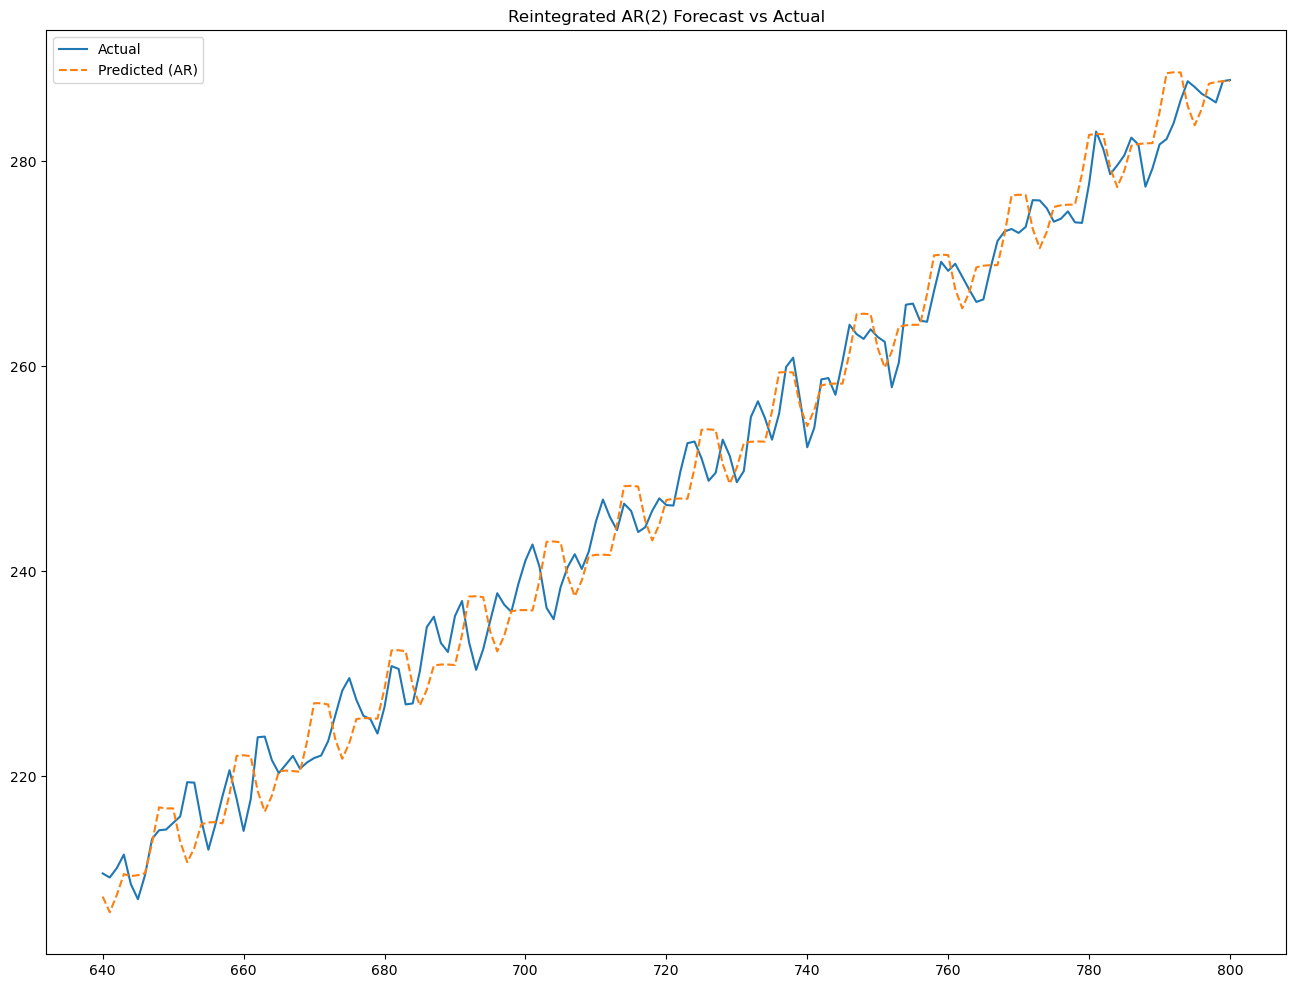

In [297]:
plt.plot(df_test.index, df_test['Values'], label='Actual')
plt.plot(df_test.index, forecast, label='Predicted (AR)', linestyle='--')
plt.legend()
plt.title("Reintegrated AR(2) Forecast vs Actual")
plt.show()

The original plot looks way off than our predictions mainly due to trend not getting captured properly

In [254]:
def MSE(y_true,y_pred):
    mse = np.mean(np.power(y_true-y_pred,2))
    return mse

In [298]:
MSE(forecast,df_test.values)

1069.9169374501364

As we can see our MSE is also a lot. Let's try to fit different models before we go back to the data

## MA Model 
For MA model the current value of Xt is based on current error as well as on regression of past errors. The no. of lags used for MA model is depicted by "q", the model is called MA(q). We will first start with ACF plot

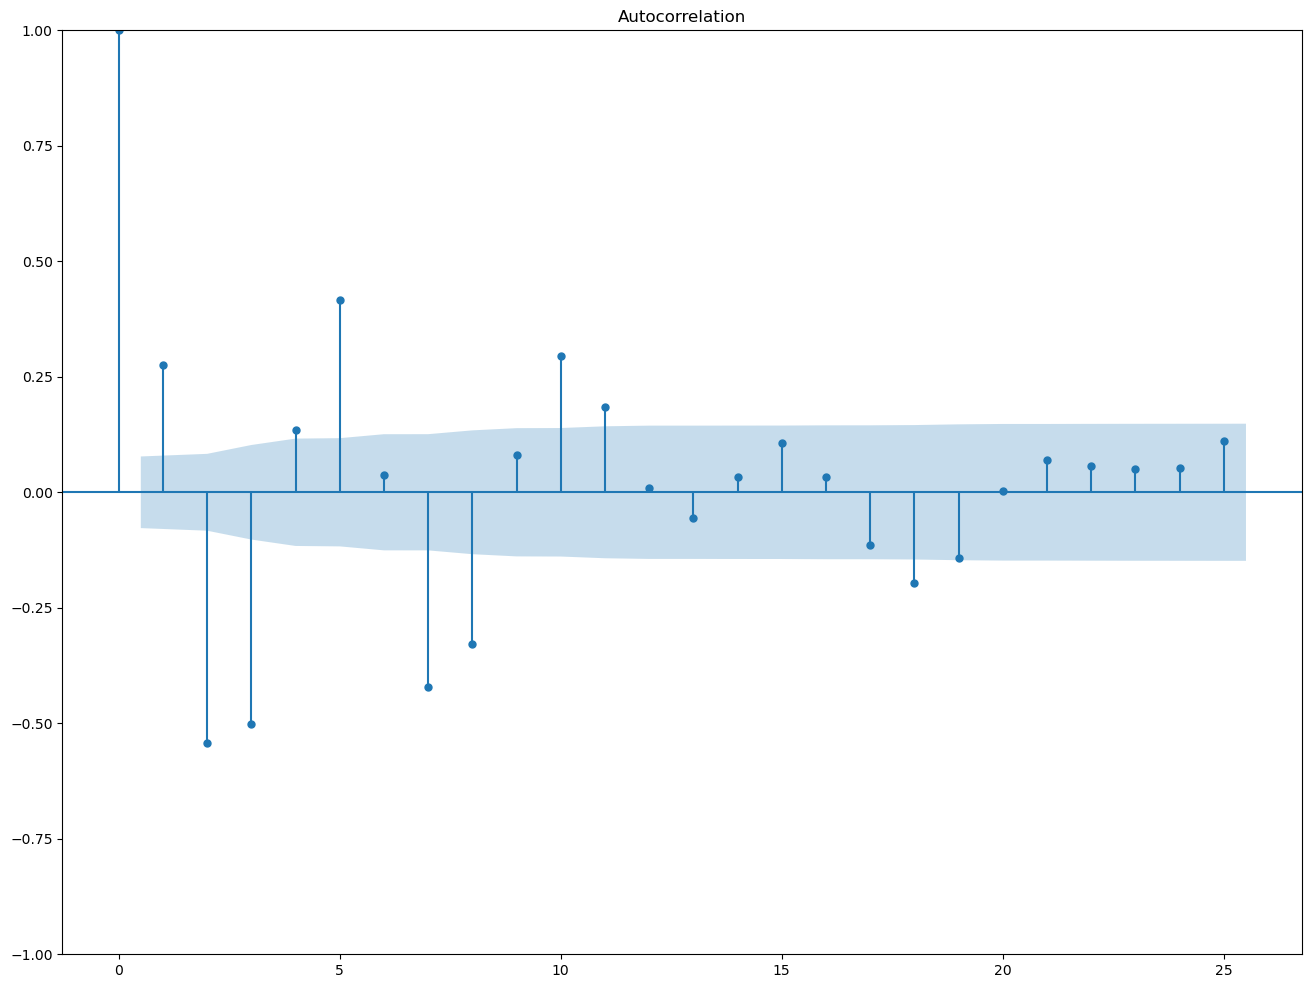

In [299]:
from statsmodels.graphics.tsaplots import plot_acf
fig = plot_acf(df_stationary['Values'],lags = 25)

Here also we applied similar logic to find q (using ACF plot). Our q comes out to be 5

In [300]:
from statsmodels.tsa.arima.model import ARIMA
MA_model = ARIMA(df_seasonal_11,order =(0,0,5)).fit()
MA_model.summary()

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Values   No. Observations:                  628
Model:                 ARIMA(0, 0, 5)   Log Likelihood               -1194.528
Date:                Mon, 14 Jul 2025   AIC                           2403.057
Time:                        20:33:47   BIC                           2434.155
Sample:                             0   HQIC                          2415.138
                                - 628                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0043      0.000     16.457      0.000       0.004       0.005
ma.L1         -0.2880      0.040     -7.152      0.000      -0.367      -0.209
ma.L2         -1.0631      0.038    -28.262      0.000      -1.137      -0.989
ma.L3         -0.5521      0.049    -11.349      0.000      -0.647      -0.457
ma.L4          0.4687      0.036     12.931      0.000       0.398       0.540
ma.L5          0.4383      0.038     11.488      0.000       0.364       0.513
sigma2         2.6530      0.168     15.799      0.000       2.324       2.982
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 2.12
Prob(Q):                              0.76   Prob(JB):                         0.35
Heteroskedasticity (H):               0.89   Skew:                            -0.04
Prob(H) (two-sided):                  0.41   Kurtosis:                         2.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [301]:
predicted_diff = MA_model.forecast(steps=len(df_test))
predicted_diff = predicted_diff.reset_index(drop=True)
predicted_diff

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


0      2.051449
1      1.540566
2     -1.316498
3     -0.875757
4      0.258936
         ...   
156    0.004281
157    0.004281
158    0.004281
159    0.004281
160    0.004281
Name: predicted_mean, Length: 161, dtype: float64

[-2.627948   -1.47168257  0.9224552   2.54075794  0.20718315 -0.98258843
 -0.38117193  3.55210227  4.21884927 -0.30914563 -0.66849033 -2.62366743
 -1.467402    0.92673576  2.54503851  0.21146372 -0.97830786 -0.37689136
  3.55638284  4.22312984 -0.30486506 -0.66420976 -2.61938686 -1.46312143
  0.93101633  2.54931908  0.21574429 -0.9740273  -0.3726108   3.5606634
  4.2274104  -0.3005845  -0.6599292  -2.61510629 -1.45884086  0.9352969
  2.55359965  0.22002486 -0.96974673 -0.36833023  3.56494397  4.23169097
 -0.29630393 -0.65564863 -2.61082573 -1.45456029  0.93957747  2.55788021
  0.22430543 -0.96546616 -0.36404966  3.56922454  4.23597154 -0.29202336
 -0.65136806 -2.60654516 -1.45027972  0.94385804  2.56216078  0.22858599
 -0.96118559 -0.35976909  3.57350511  4.24025211 -0.28774279 -0.64708749
 -2.60226459 -1.44599916  0.94813861  2.56644135  0.23286656 -0.95690502
 -0.35548852  3.57778568  4.24453268 -0.28346222 -0.64280692 -2.59798402
 -1.44171859  0.95241917  2.57072192  0.23714713 -0.9

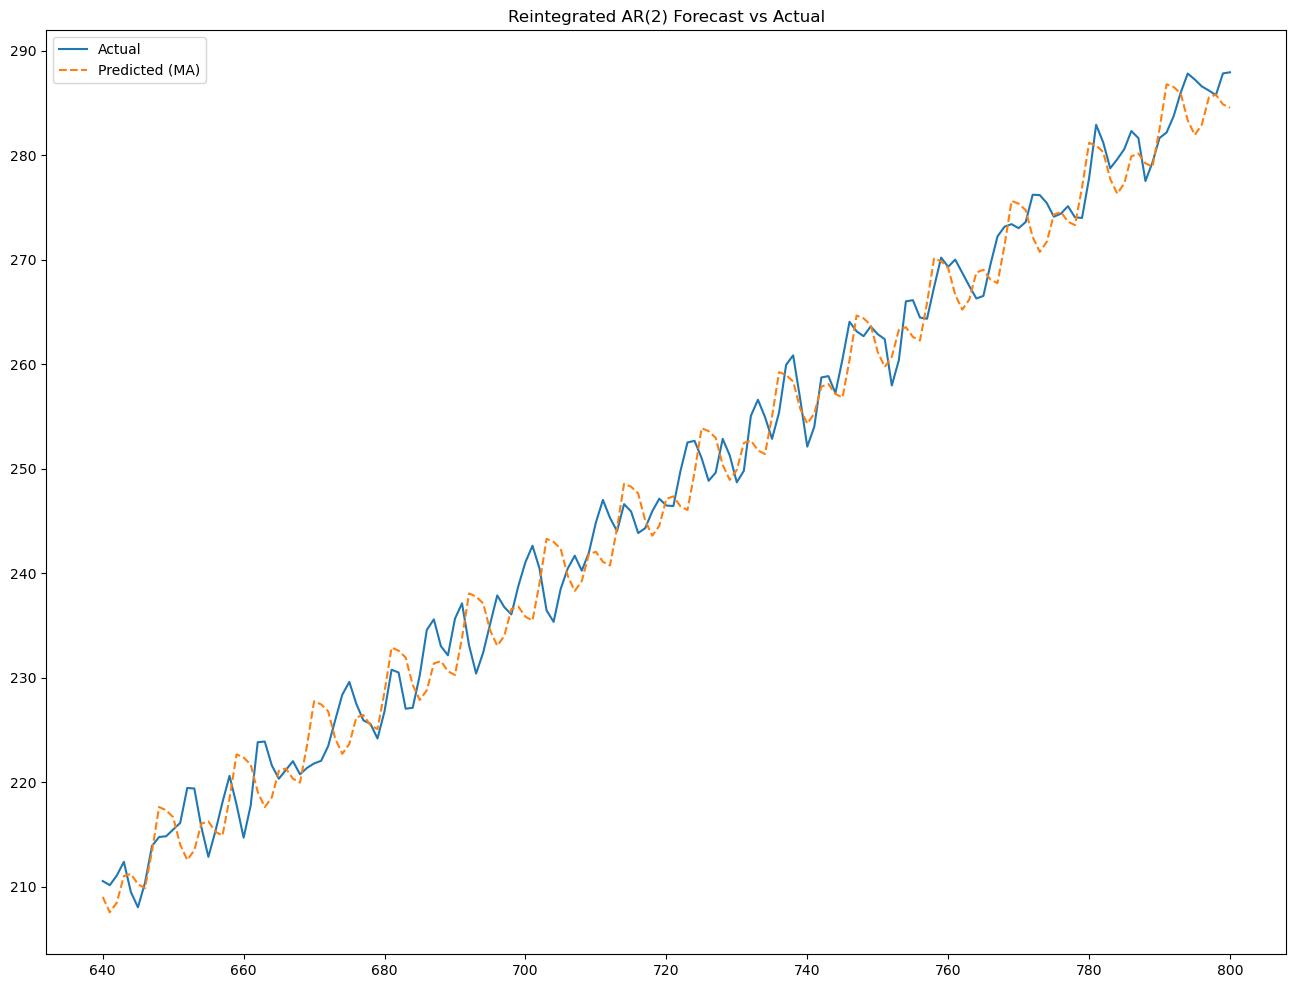

1033.317562814504

In [302]:
forecast = add_seasonality(predicted_diff,df_stationary,11)
forecast = add_trend(df_train,forecast)

plt.plot(df_test.index, df_test['Values'], label='Actual')
plt.plot(df_test.index, forecast, label='Predicted (MA)', linestyle='--')
plt.legend()
plt.title("Reintegrated AR(2) Forecast vs Actual")
plt.show()
MSE(forecast,df_test.values)

Only MA model's fit has been better as RMSE is reduced to 1048 to 3.4k

Let's try ARIMA model (differencing of 1 is already done)

## ARMA model (p,1,q)

We will try ARMA model together on stationary data. Let's first see ARIMA of order (2,1,2)

In [343]:
ARMA_model = ARIMA(df_seasonal_11,order =(4,0,5)).fit()
ARMA_model.summary()

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood opt

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 Values   No. Observations:                  628
Model:                 ARIMA(4, 0, 5)   Log Likelihood               -1154.834
Date:                Mon, 14 Jul 2025   AIC                           2331.668
Time:                        21:30:06   BIC                           2380.536
Sample:                             0   HQIC                          2350.652
                                - 628                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0044      0.001      7.124      0.000       0.003       0.006
ar.L1         -0.5493      0.047    -11.733      0.000      -0.641      -0.458
ar.L2         -1.6224      0.038    -42.706      0.000      -1.697      -1.548
ar.L3         -0.5861      0.044    -13.230      0.000      -0.673      -0.499
ar.L4         -0.8138      0.038    -21.405      0.000      -0.888      -0.739
ma.L1          0.3276      0.100      3.291      0.001       0.133       0.523
ma.L2          0.6990      0.128      5.481      0.000       0.449       0.949
ma.L3         -0.7897      0.185     -4.265      0.000      -1.153      -0.427
ma.L4         -0.4967      0.122     -4.066      0.000      -0.736      -0.257
ma.L5         -0.7315      0.082     -8.899      0.000      -0.893      -0.570
sigma2         2.2611      0.257      8.791      0.000       1.757       2.765
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 3.31
Prob(Q):                              0.96   Prob(JB):                         0.19
Heteroskedasticity (H):               0.92   Skew:                             0.10
Prob(H) (two-sided):                  0.53   Kurtosis:                         2.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [344]:
predicted_diff = ARMA_model.forecast(steps=len(df_test))
predicted_diff = predicted_diff.reset_index(drop=True)
predicted_diff

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


0      2.988309
1      1.315698
2     -3.435792
3     -1.479493
4      2.202453
         ...   
156    1.674108
157    0.872214
158   -1.443254
159   -1.204570
160    1.149615
Name: predicted_mean, Length: 161, dtype: float64

[-1.69108846 -1.69655024 -1.1968393   1.93702211  2.15070044  1.16671016
 -1.45871129  0.57633999  4.55346038  3.21790504 -0.52739325 -5.26089453
 -2.29715937  1.98587359  3.15715248 -0.40629767 -0.76506468  0.46575074
  3.17912378  3.23443406  0.1835927   0.20769473 -2.06674944 -2.37255452
 -1.09668459  2.52231175  2.40847473  0.60678867 -1.95406875  1.16934396
  5.1896726   2.69216318 -1.17542867 -4.86756036 -1.63155647  1.82960833
  2.49975832 -0.46201515 -0.0780907   0.73112072  2.5262655   2.84504771
  0.78197425  0.71731066 -2.51816031 -2.94541142 -0.79541987  3.17596866
  2.30359794 -0.06666667 -2.00241418  1.85792966  5.40979181  2.07029435
 -1.5153641  -4.32140956 -1.15482156  1.426798    1.94392432 -0.18717683
  0.56073601  0.62773835  1.87768599  2.81081084  1.43364358  0.9190212
 -3.09853544 -3.26811601 -0.28522376  3.63515781  1.92489407 -0.60022396
 -1.73938081  2.46724756  5.30909735  1.45690529 -1.54638971 -3.70616034
 -0.96112871  0.87939706  1.63484842  0.29637156  0.

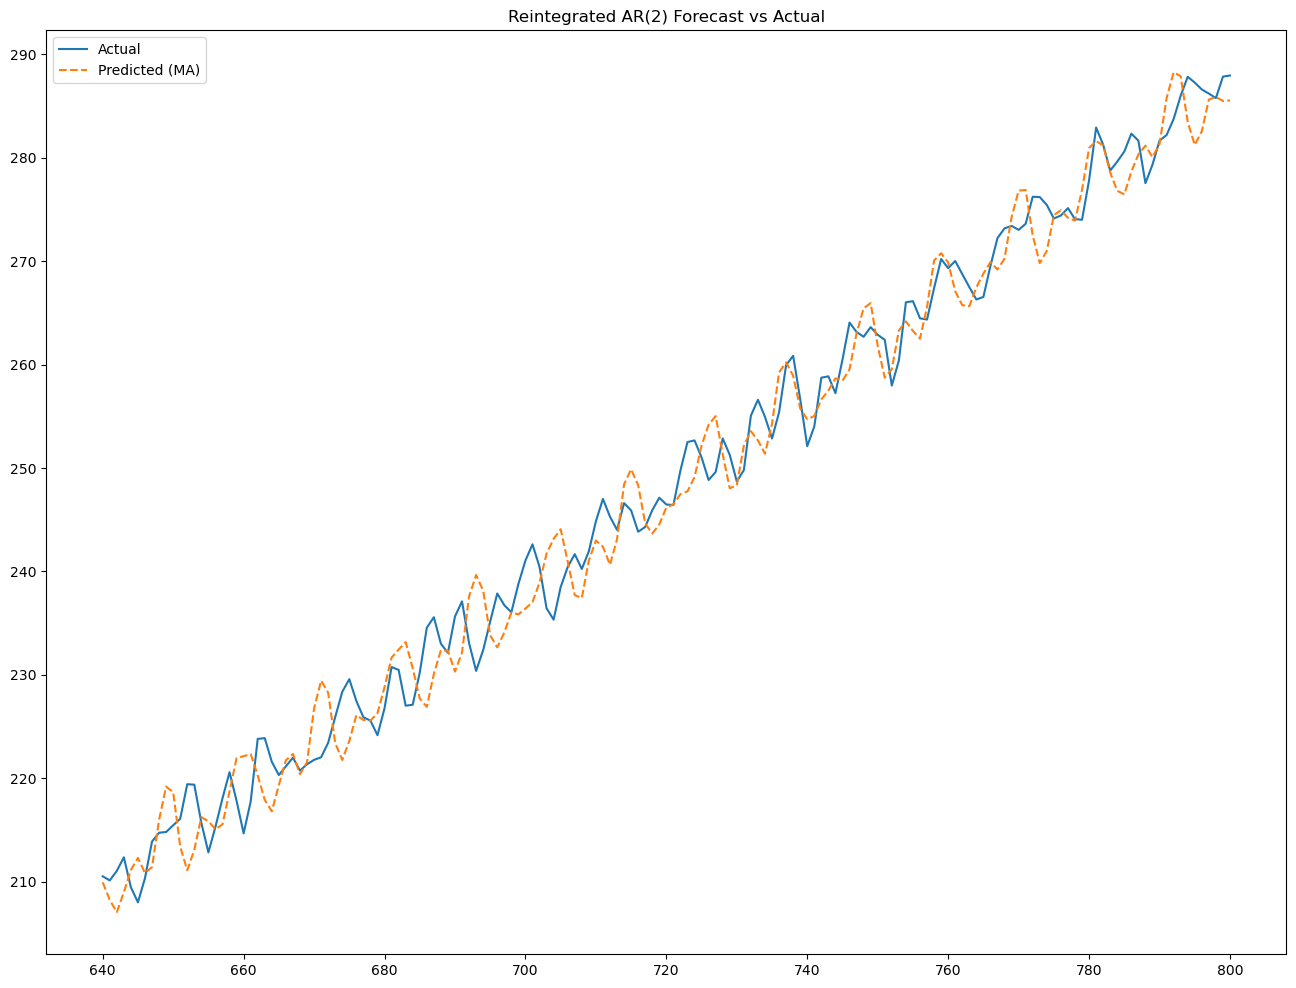

1038.9343624793876

In [345]:
forecast = add_seasonality(predicted_diff,df_stationary,11)
forecast = add_trend(df_train,forecast)

plt.plot(df_test.index, df_test['Values'], label='Actual')
plt.plot(df_test.index, forecast, label='Predicted (MA)', linestyle='--')
plt.legend()
plt.title("Reintegrated AR(2) Forecast vs Actual")
plt.show()
MSE(forecast,df_test.values)

### Auto Arima

Auto Arima gives us the best values of p,d,q according to our data. Let's see what values we get from Auto Arima and then see our Model

In [283]:
from pmdarima import auto_arima
stepwise_model = auto_arima(df_train,
                            seasonal = True,
                            m=11,  #Since our Data is seasonality of 10 or 11 we will try to go with seasonality of 11
                            trace = True, #prints progress
                            error_action = 'ignore',
                            supress_warnings = True,
                            stepwise=True #for faster convergence
                            )
print(stepwise_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[11] intercept   : AIC=2289.176, Time=2.24 sec
 ARIMA(0,1,0)(0,0,0)[11] intercept   : AIC=2812.023, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[11] intercept   : AIC=2754.977, Time=0.31 sec
 ARIMA(0,1,1)(0,0,1)[11] intercept   : AIC=2631.217, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[11]             : AIC=2824.250, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[11] intercept   : AIC=2348.550, Time=0.64 sec
 ARIMA(2,1,2)(1,0,0)[11] intercept   : AIC=2293.643, Time=1.11 sec
 ARIMA(2,1,2)(2,0,1)[11] intercept   : AIC=2287.005, Time=5.02 sec
 ARIMA(2,1,2)(2,0,0)[11] intercept   : AIC=2285.341, Time=3.17 sec
 ARIMA(1,1,2)(2,0,0)[11] intercept   : AIC=2433.296, Time=1.25 sec
 ARIMA(2,1,1)(2,0,0)[11] intercept   : AIC=2332.238, Time=1.34 sec
 ARIMA(3,1,2)(2,0,0)[11] intercept   : AIC=2329.815, Time=5.53 sec
 ARIMA(2,1,3)(2,0,0)[11] intercept   : AIC=2264.341, Time=2.60 sec
 ARIMA(2,1,3)(1,0,0)[11] intercept   : AIC=2270.596, Time=1.02 sec
 ARIMA(2,1,3)(2,0,1

In [273]:
stepwise_model

ARIMA(order=(4, 1, 5), scoring_args={}, seasonal_order=(1, 0, 0, 11),
      suppress_warnings=True)

In [284]:
predicted_diff = stepwise_model.predict(n_periods = len(df_test))
predicted_diff = predicted_diff.reset_index(drop=True)
predicted_diff

0      209.444195
1      207.774412
2      208.926064
3      209.676142
4      210.140933
          ...    
156    261.274428
157    261.601798
158    261.929029
159    262.256249
160    262.583386
Length: 161, dtype: float64

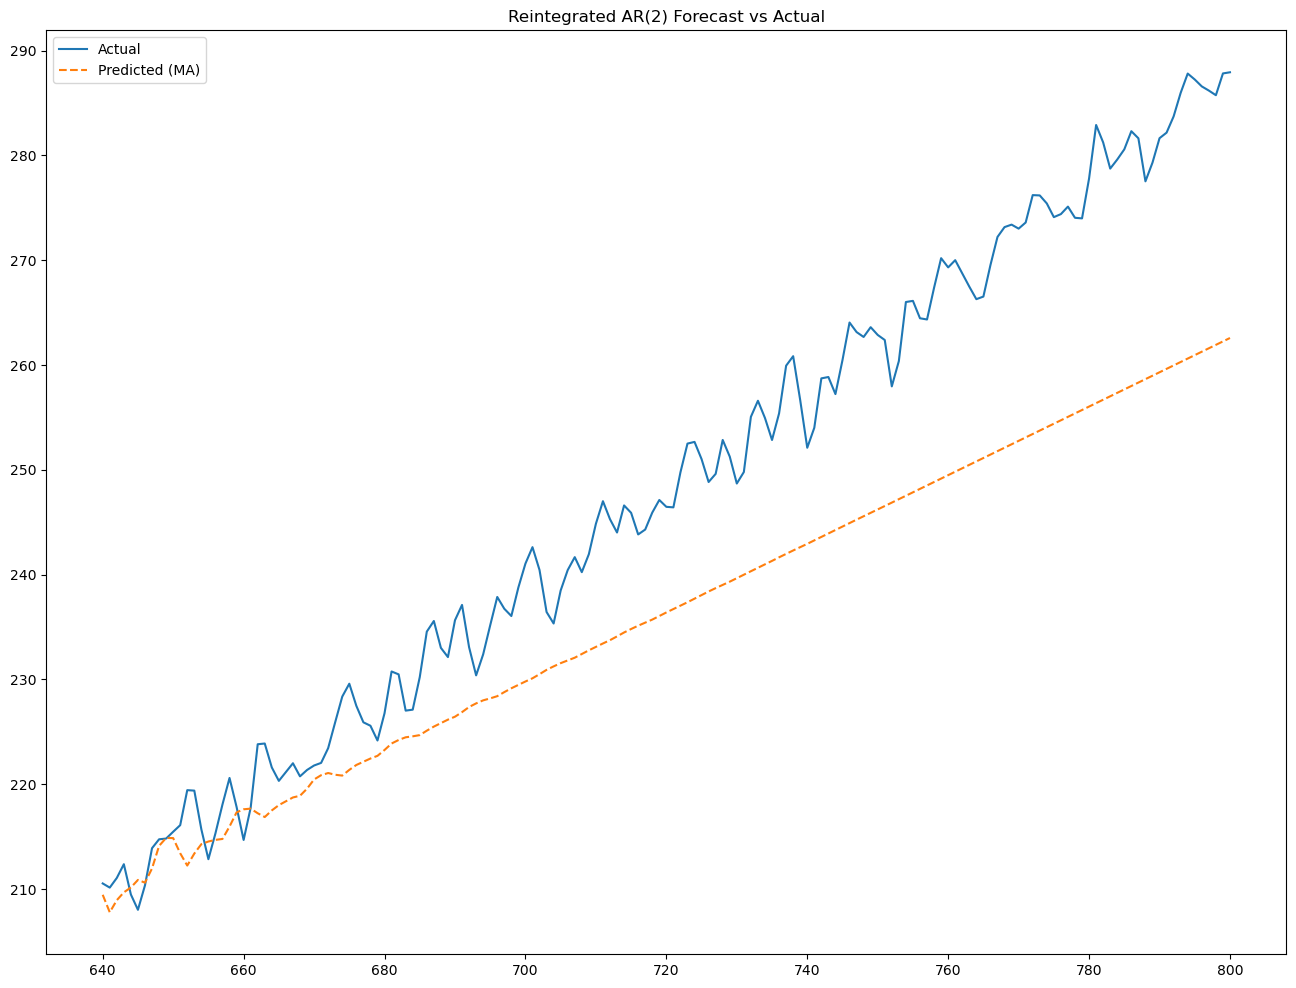

896.2621490991838

In [285]:
plt.plot(df_test.index, df_test['Values'], label='Actual')
plt.plot(df_test.index, predicted_diff, label='Predicted (MA)', linestyle='--')
plt.legend()
plt.title("Reintegrated AR(2) Forecast vs Actual")
plt.show()
MSE(predicted_diff.values,df_test.values)

Though MSE is better than all of our models but the fit looks terrible

## SARIMA Parameters
SARIMA's parameters are (p,d,q)(P,D,Q)(S), where (p,d,q) are components of non-sesonal component that we have already found through our analysis, i.e (4,1,5). S is 11 since our best fit came from the data that had seasonal differencing of 11, So we have (4,1,5)(P,1,Q)(11). We will now find P and Q.

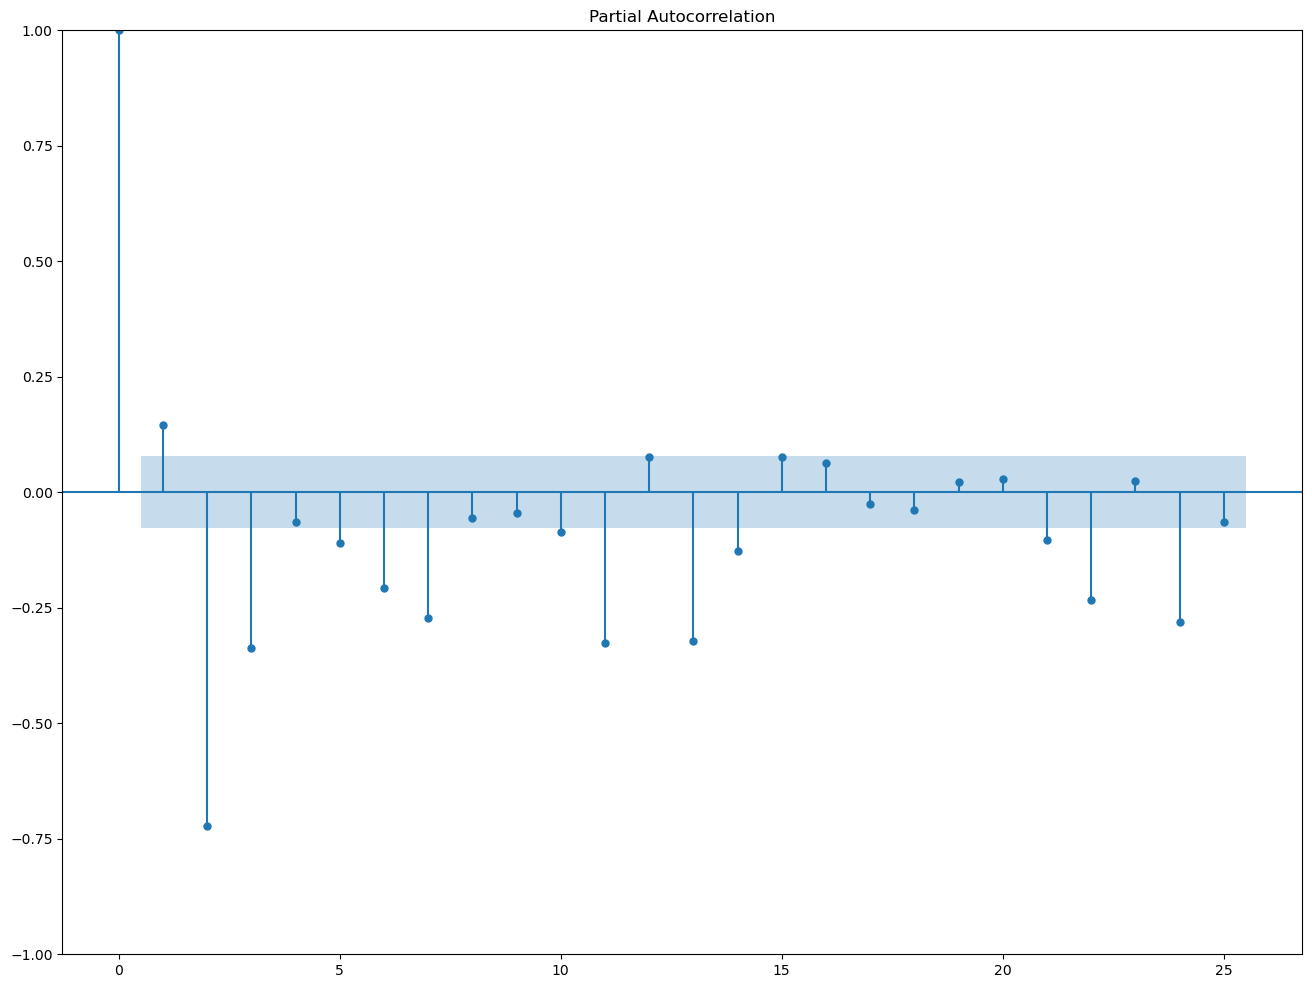

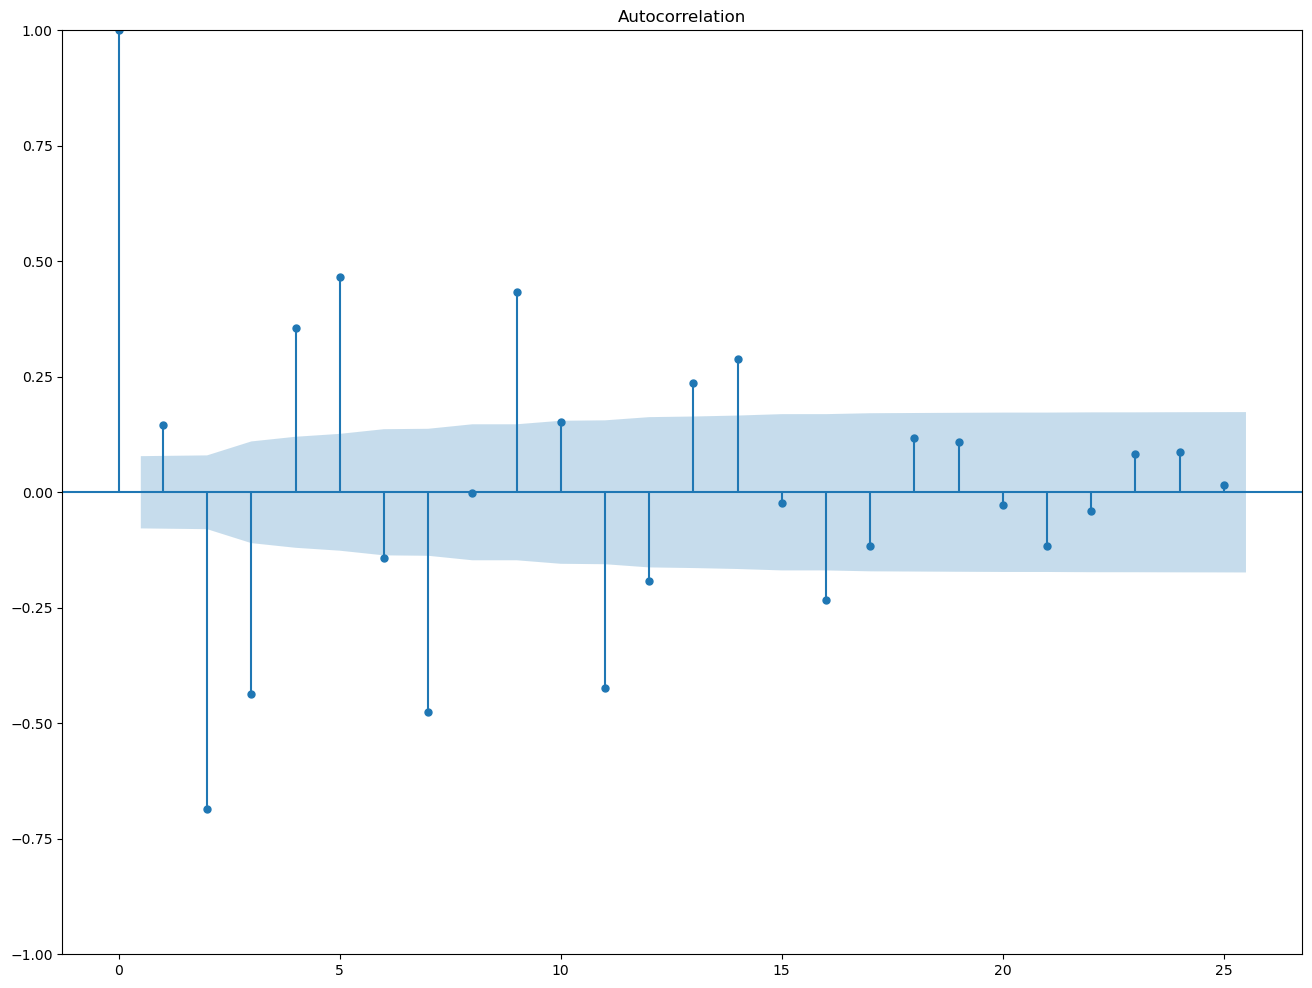

In [307]:
fig = plot_pacf(df_seasonal_11['Values'],lags = 25)
fig = plot_acf(df_seasonal_11['Values'],lags = 25)

From above analysis P is 3 and Q is 7 or 5

In [347]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df_train, order=(4, 1, 5), seasonal_order=(3, 1, 5, 11))
result = model.fit()

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           18     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.28200D+00    |proj g|=  1.31585D+00

At iterate    5    f=  1.79248D+00    |proj g|=  1.05386D-01

At iterate   10    f=  1.75950D+00    |proj g|=  4.06794D-02

At iterate   15    f=  1.74888D+00    |proj g|=  4.32334D-02

At iterate   20    f=  1.73788D+00    |proj g|=  1.01353D-01

At iterate   25    f=  1.73319D+00    |proj g|=  1.14074D-02

At iterate   30    f=  1.72821D+00    |proj g|=  1.81215D-01

At iterate   35    f=  1.72214D+00    |proj g|=  3.68201D-01

At iterate   40    f=  1.70887D+00    |proj g|=  1.06773D-01

At iterate   45    f=  1.69400D+00    |proj g|=  8.91020D-02


/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f=  1.67080D+00    |proj g|=  5.36822D-01

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   18     50     63      1     0     0   5.368D-01   1.671D+00
  F =   1.6707984290614291     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


In [348]:
predicted_diff = result.forecast(steps = len(df_test))
predicted_diff = predicted_diff.reset_index(drop=True)
predicted_diff

0      208.905472
1      208.152277
2      209.014484
3      210.564146
4      210.795185
          ...    
156    272.914491
157    274.237015
158    274.219209
159    273.979469
160    274.024682
Name: predicted_mean, Length: 161, dtype: float64

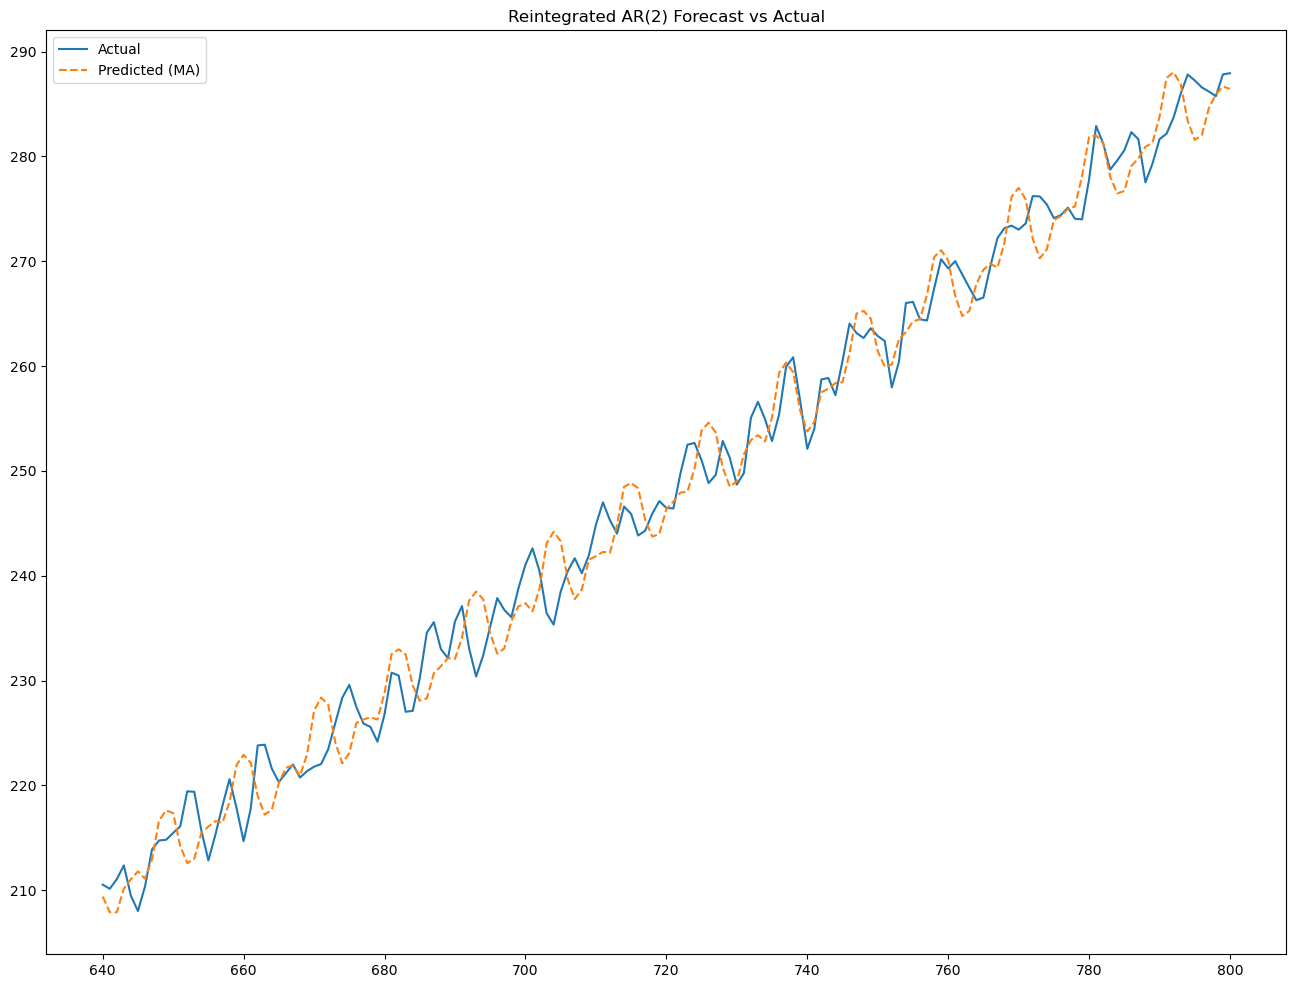

1040.6728492404452

In [318]:
plt.plot(df_test.index, df_test['Values'], label='Actual')
plt.plot(df_test.index, predicted_diff, label='Predicted (MA)', linestyle='--')
plt.legend()
plt.title("Reintegrated AR(2) Forecast vs Actual")
plt.show()
MSE(predicted_diff.values,df_test.values)

Let's Submit the above Model 

In [361]:
model = SARIMAX(df, order=(4, 1, 5), seasonal_order=(3, 2, 5, 11))
result = model.fit()

/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           18     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.12342D+00    |proj g|=  3.99700D-01

At iterate    5    f=  1.96408D+00    |proj g|=  2.11117D-01

At iterate   10    f=  1.82593D+00    |proj g|=  9.13343D-02

At iterate   15    f=  1.80100D+00    |proj g|=  1.38766D-01

At iterate   20    f=  1.78738D+00    |proj g|=  4.14936D-02

At iterate   25    f=  1.77699D+00    |proj g|=  6.49840D-02

At iterate   30    f=  1.77234D+00    |proj g|=  4.51267D-02

At iterate   35    f=  1.77115D+00    |proj g|=  6.14187D-02

At iterate   40    f=  1.76970D+00    |proj g|=  2.48127D-02

At iterate   45    f=  1.76853D+00    |proj g|=  1.16545D-02


/usr/local/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f=  1.76771D+00    |proj g|=  2.06797D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   18     50     56      1     0     0   2.068D-02   1.768D+00
  F =   1.7677073063560391     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


In [355]:
# Step 2: Set start and end for forecasting
start = df.index[-1] + 1  # 801
end = 999                 # inclusive

# Step 3: Get prediction
forecast_result = result.get_prediction(start=start, end=end)
forecast = forecast_result.predicted_mean

# Step 4: Build DataFrame
forecast_df = pd.DataFrame({
    'Id': np.arange(start, end + 1),
    'Values': forecast.values
})

# Step 5: Save to CSV
forecast_df.to_csv("forecast_801_to_999_2.csv", index=False)

**SARIMAX of 2 is giving us the best result out there with Score board RMSE of just 7 improved from RMSE of 57**. We tried to apply seasonal differencing of 3 as well, however the RMSE started dropping. To improve the results further we can make a grid of various SARIMA combinations anc check the select the lowest RMSE data but D = 2 might have worked better because our data has stronger or more persistent seasonal effects